<a href="https://colab.research.google.com/github/satriopriyo/eda_analysis/blob/main/Filtering_Loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import os

# =============== FILTER FUNCTIONS ====================

def amplitude_notch_filter(signal, threshold=0.5, window=5):
    """
    Suppress parts of `signal` where amplitude > threshold.
    Smooth replace with interpolation.
    """
    signal = np.array(signal, dtype=float)
    out = signal.copy()
    idxs = np.where(signal > threshold)[0]

    for idx in idxs:
        left = max(0, idx - window)
        right = min(len(signal), idx + window)

        if right - left <= 1:
            out[idx] = (signal[left] + signal[right - 1]) / 2.0
            continue

        x = np.arange(left, right)
        x_bound = np.array([left, right - 1])
        y_bound = np.array([signal[left], signal[right - 1]])
        out[left:right] = np.interp(x, x_bound, y_bound)

    return out


def bandpass_filter(signal, lowcut=0.5, highcut=3.5, fs=8, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal


# =============== LOOP THROUGH FOLDER ====================

data_folder = "Data"
output_folder = "Processed"

os.makedirs(output_folder, exist_ok=True)

sampling_rate = 8  # change this to your true EDA sampling rate
eda_column = "uS"

for file in os.listdir(data_folder):
    if file.endswith(".csv"):
        file_path = os.path.join(data_folder, file)
        print(f"Processing: {file}")

        # --- Load data ---
        df = pd.read_csv(file_path, delimiter=",", skiprows=[0,1])

        if eda_column not in df.columns:
            print(f"  !! Column {eda_column} not found in {file}. Skipping.")
            continue

        eda_raw = df[eda_column].values

        # --- Notch filter ---
        eda_notched = amplitude_notch_filter(eda_raw)

        # --- Bandpass filter ---
        eda_filtered = bandpass_filter(
            eda_notched,
            lowcut=0.5,
            highcut=3.5,
            fs=sampling_rate,
            order=4
        )

        # --- Save filtered data ---
        df["EDA_Filtered"] = eda_filtered
        out_csv = os.path.join(output_folder, f"{file.replace('.csv', '')}_filtered.csv")
        df.to_csv(out_csv, index=False)

        # --- Plot and save PNG ---
        plt.figure(figsize=(12, 5))
        plt.plot(eda_raw, label="Raw EDA", alpha=0.4)
        plt.plot(eda_filtered, label="Filtered EDA", linewidth=2)
        plt.title(f"Filtered EDA - {file}")
        plt.xlabel("Time")
        plt.ylabel("EDA (µS)")
        plt.legend()

        out_png = os.path.join(output_folder, f"{file.replace('.csv', '')}_plot.png")
        plt.savefig(out_png)
        plt.close()

        print(f"  → Saved CSV: {out_csv}")
        print(f"  → Saved PNG: {out_png}")

print("\n🎉 ALL FILES PROCESSED SUCCESSFULLY!")

Processing: E7.indo.csv
  → Saved CSV: Processed/E7.indo_filtered.csv
  → Saved PNG: Processed/E7.indo_plot.png
Processing: E6.western.csv
  → Saved CSV: Processed/E6.western_filtered.csv
  → Saved PNG: Processed/E6.western_plot.png
Processing: E5.baseline.csv
  → Saved CSV: Processed/E5.baseline_filtered.csv
  → Saved PNG: Processed/E5.baseline_plot.png
Processing: E3.indo.csv
  → Saved CSV: Processed/E3.indo_filtered.csv
  → Saved PNG: Processed/E3.indo_plot.png
Processing: E3.western.csv
  → Saved CSV: Processed/E3.western_filtered.csv
  → Saved PNG: Processed/E3.western_plot.png
Processing: I3.western.csv
  → Saved CSV: Processed/I3.western_filtered.csv
  → Saved PNG: Processed/I3.western_plot.png
Processing: I5.indo.csv
  → Saved CSV: Processed/I5.indo_filtered.csv
  → Saved PNG: Processed/I5.indo_plot.png
Processing: I3.baseline.csv
  → Saved CSV: Processed/I3.baseline_filtered.csv
  → Saved PNG: Processed/I3.baseline_plot.png
Processing: I4.western.csv
  → Saved CSV: Processed/I


Loaded 39 participants.
Running cvxEDA on E6.baseline_filtered.csv
     pcost       dcost       gap    pres   dres
 0: -1.1056e+00 -1.6494e-01  4e+02  2e+01  1e+01
 1: -1.3739e+00 -5.1409e+01  6e+01  3e+00  2e+00
 2: -8.1010e+00 -4.7982e+01  4e+01  2e+00  1e+00
 3: -1.2173e+01 -5.1899e+01  4e+01  1e+00  9e-01
 4: -2.6174e+01 -4.5342e+01  2e+01  6e-01  4e-01
 5: -3.4866e+01 -5.3232e+01  2e+01  5e-01  3e-01
 6: -4.3346e+01 -6.3248e+01  2e+01  4e-01  2e-01
 7: -5.3540e+01 -6.9574e+01  2e+01  2e-01  1e-01
 8: -6.1505e+01 -7.7874e+01  2e+01  2e-01  1e-01
 9: -6.8924e+01 -8.4958e+01  2e+01  1e-01  7e-02
10: -7.3717e+01 -8.9064e+01  2e+01  8e-02  5e-02
11: -7.6514e+01 -9.2604e+01  2e+01  8e-02  5e-02
12: -8.2798e+01 -9.7621e+01  1e+01  6e-02  3e-02
13: -8.9010e+01 -1.0474e+02  2e+01  4e-02  2e-02
14: -9.3068e+01 -1.0677e+02  1e+01  2e-02  1e-02
15: -9.4402e+01 -1.0626e+02  1e+01  1e-02  9e-03
16: -9.5265e+01 -1.0459e+02  9e+00  1e-02  6e-03
17: -9.6093e+01 -1.0065e+02  5e+00  2e-03  1e-03
18

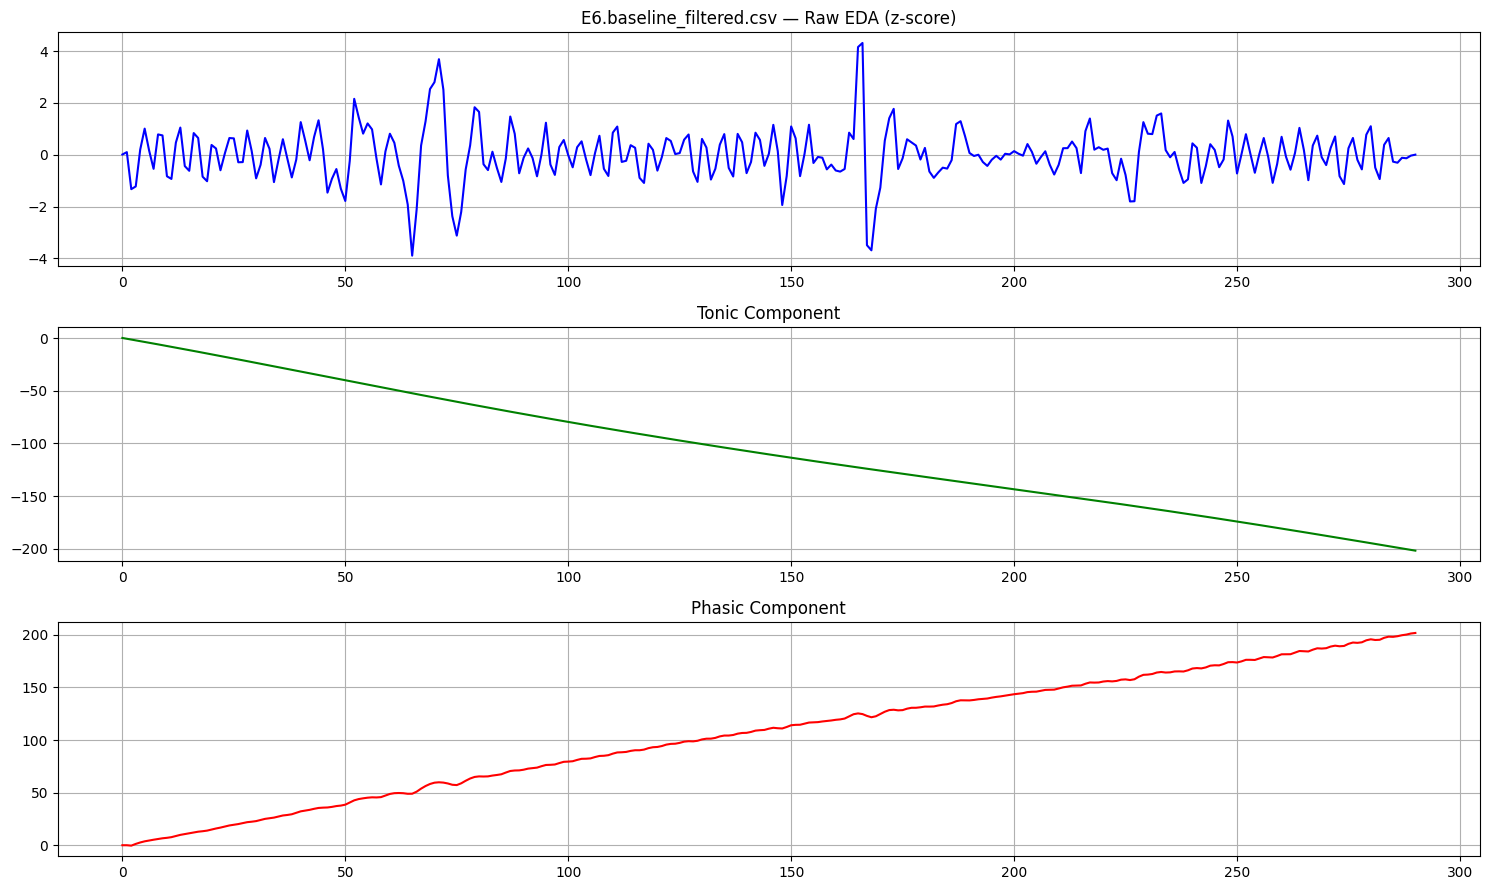

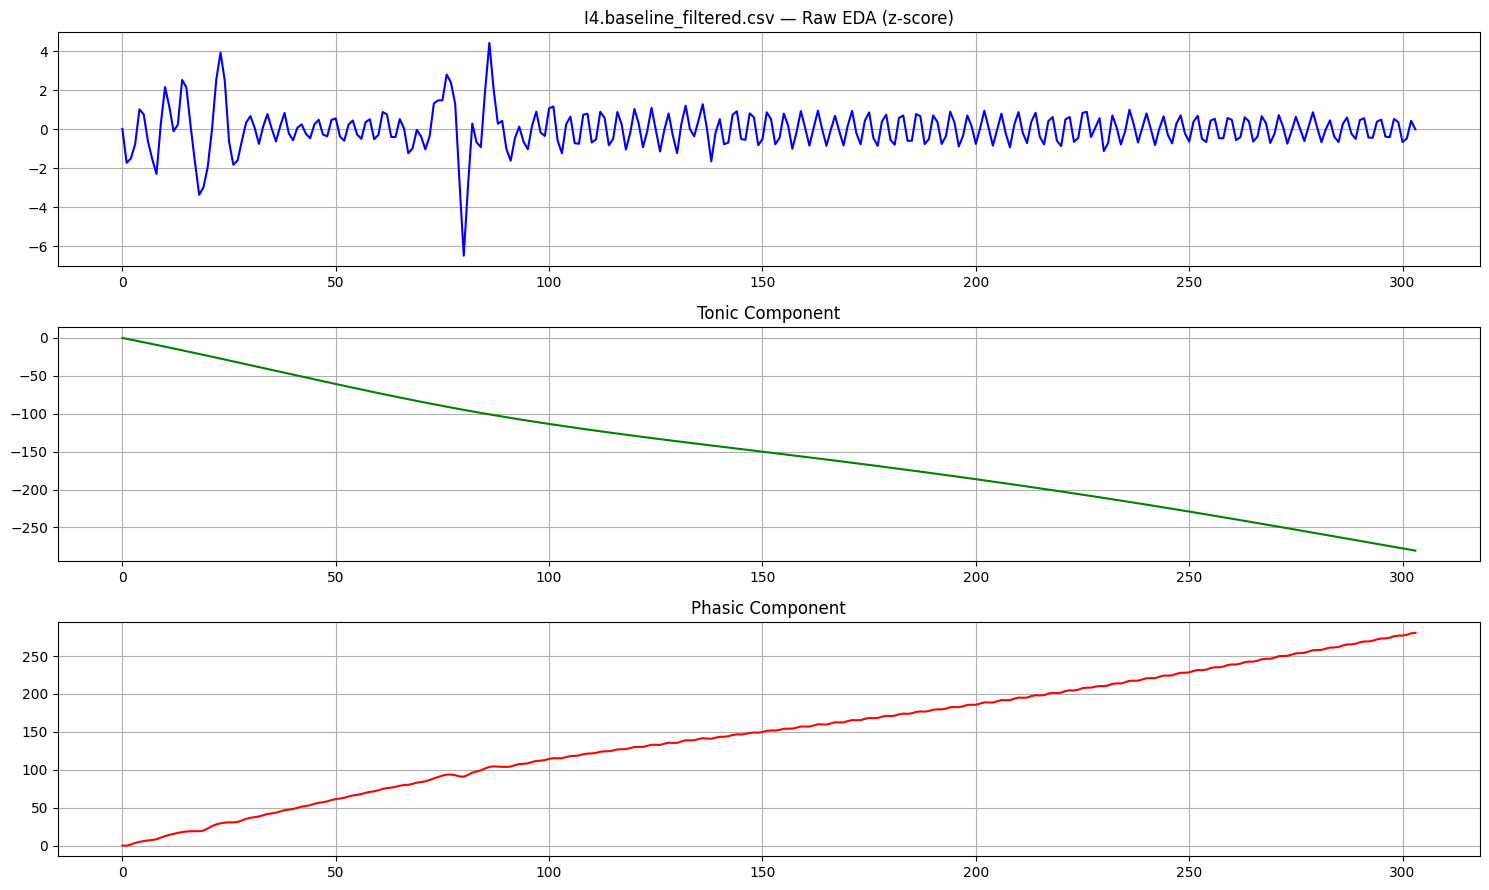

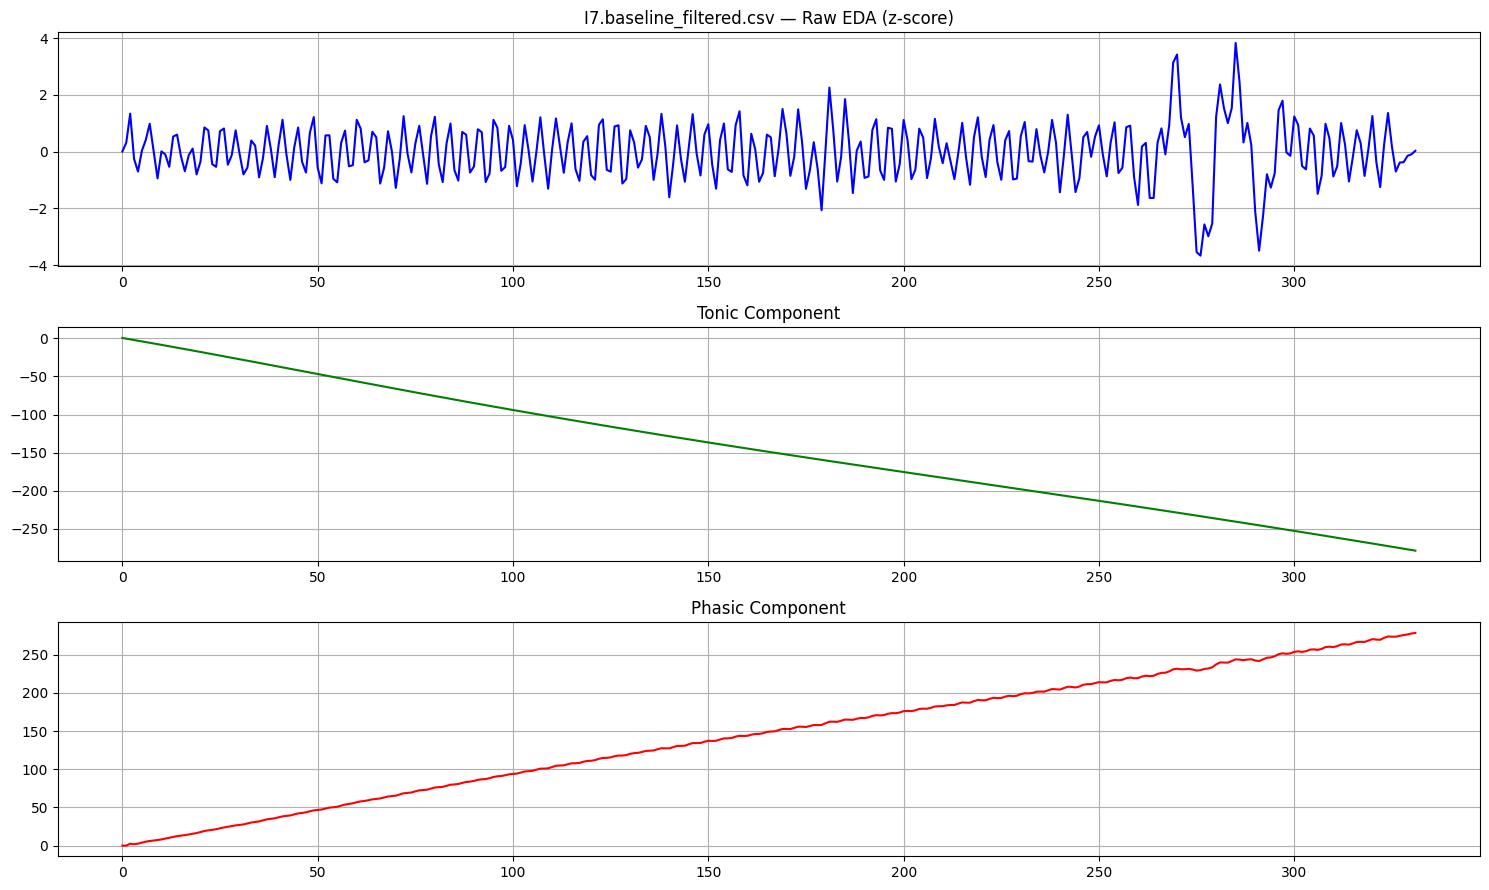

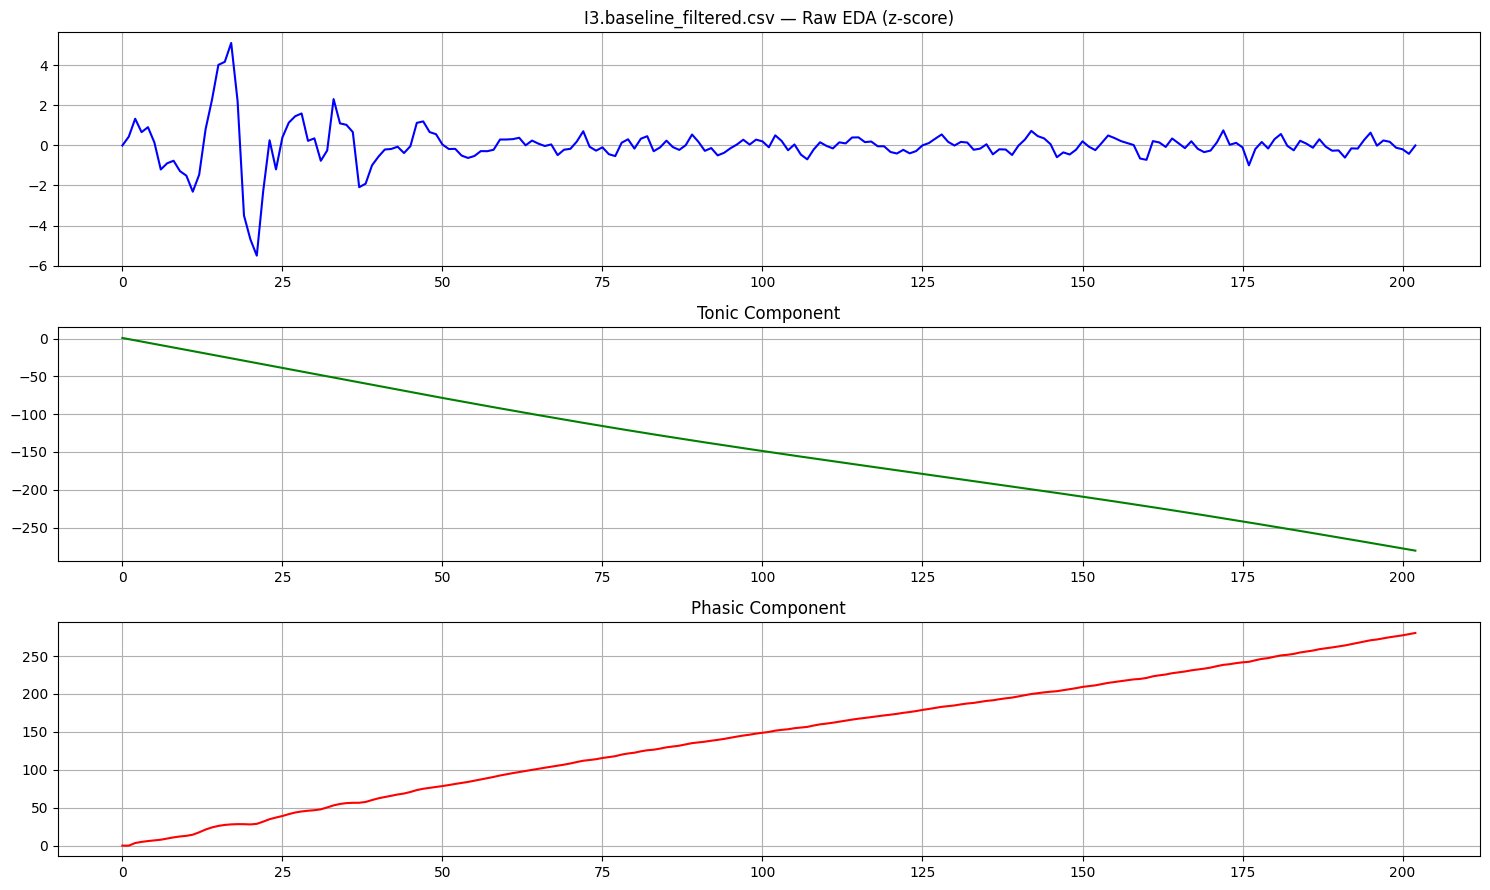

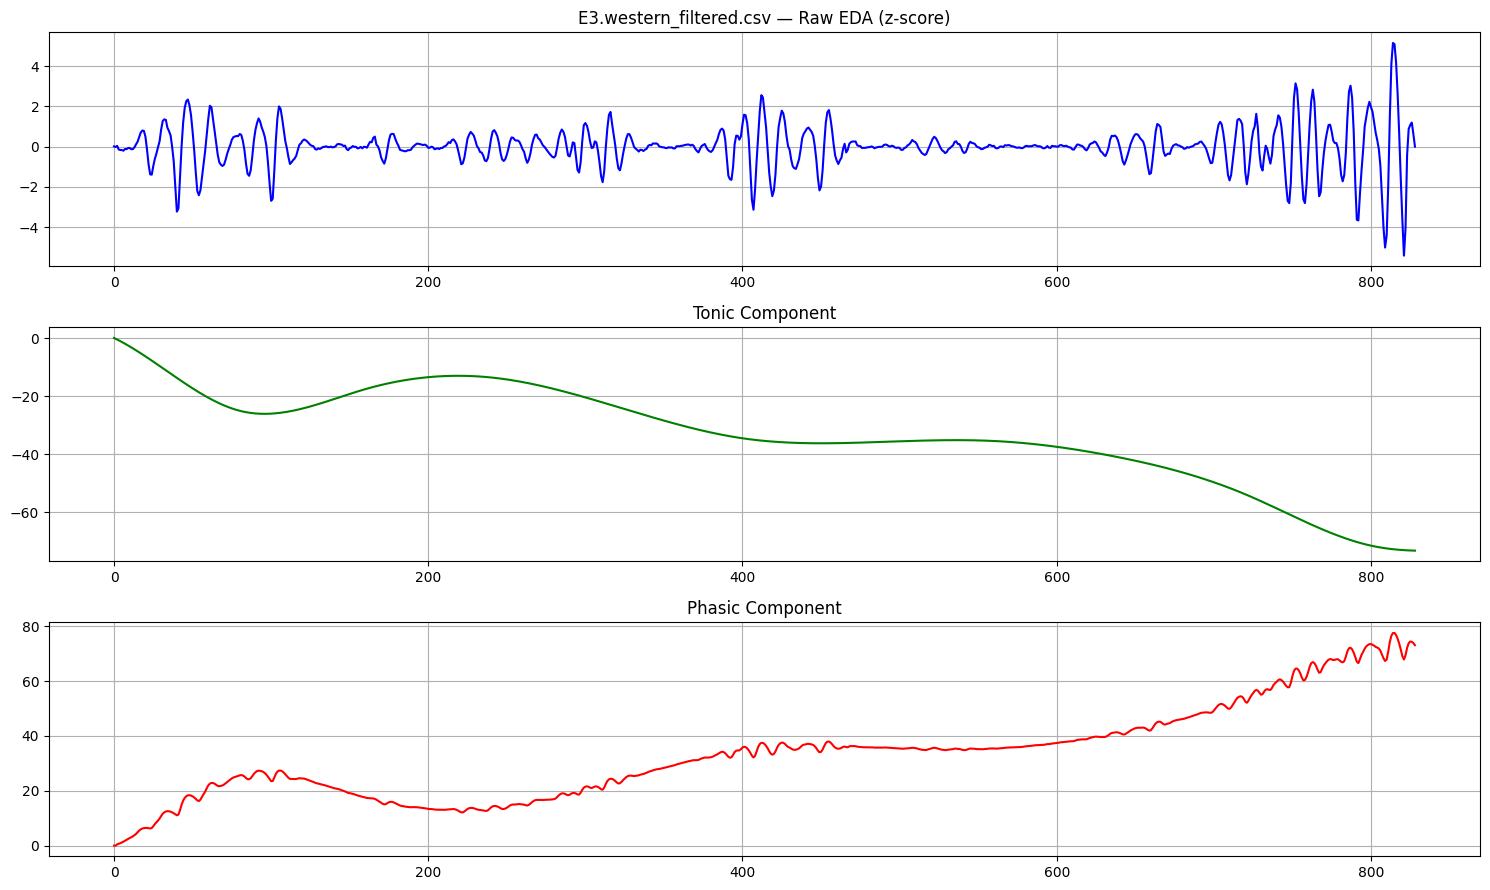

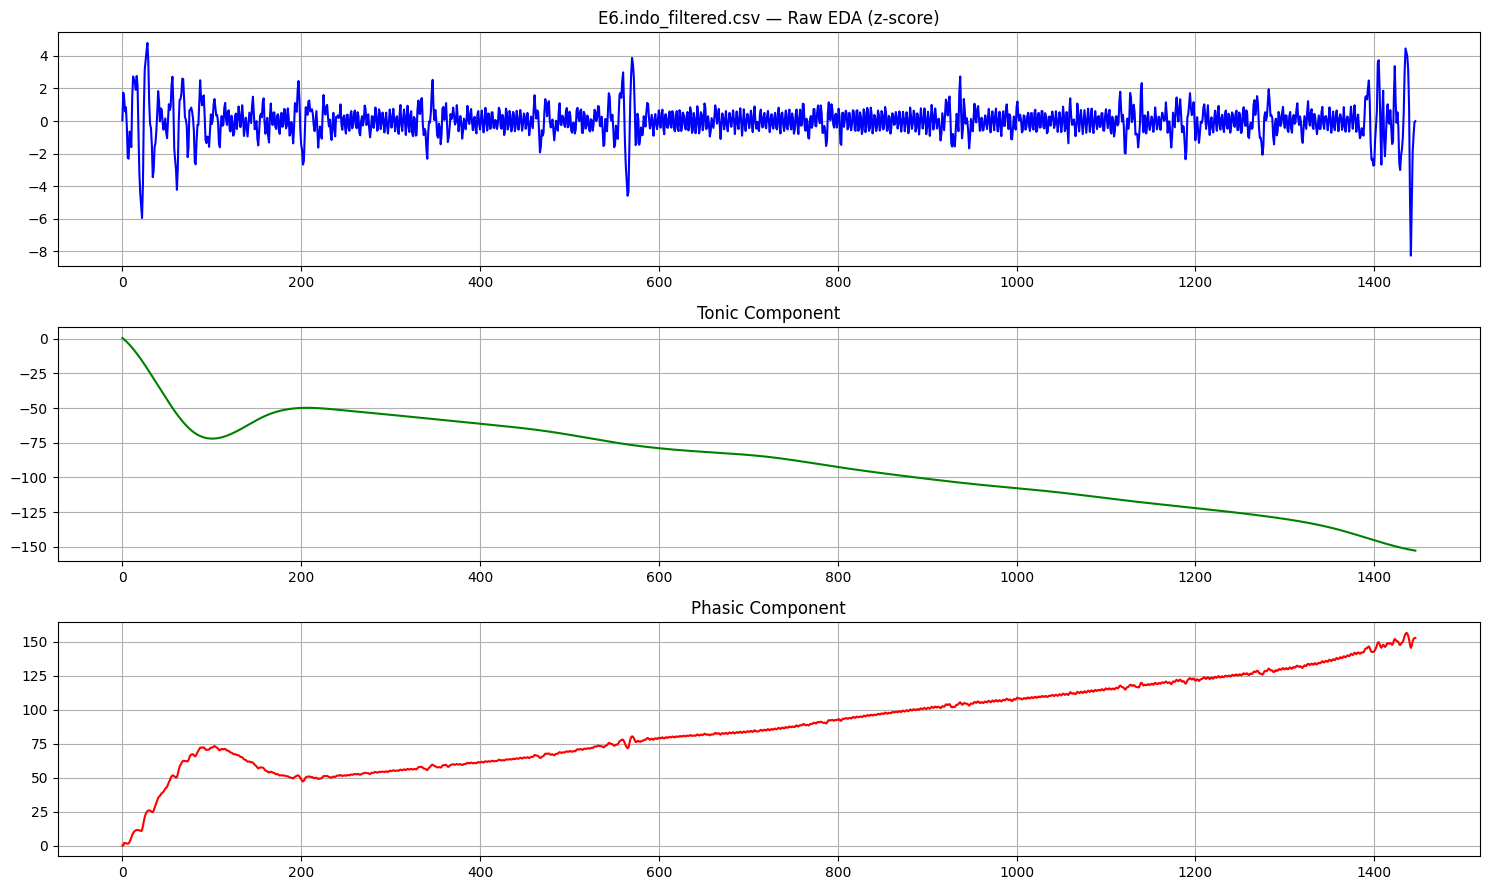

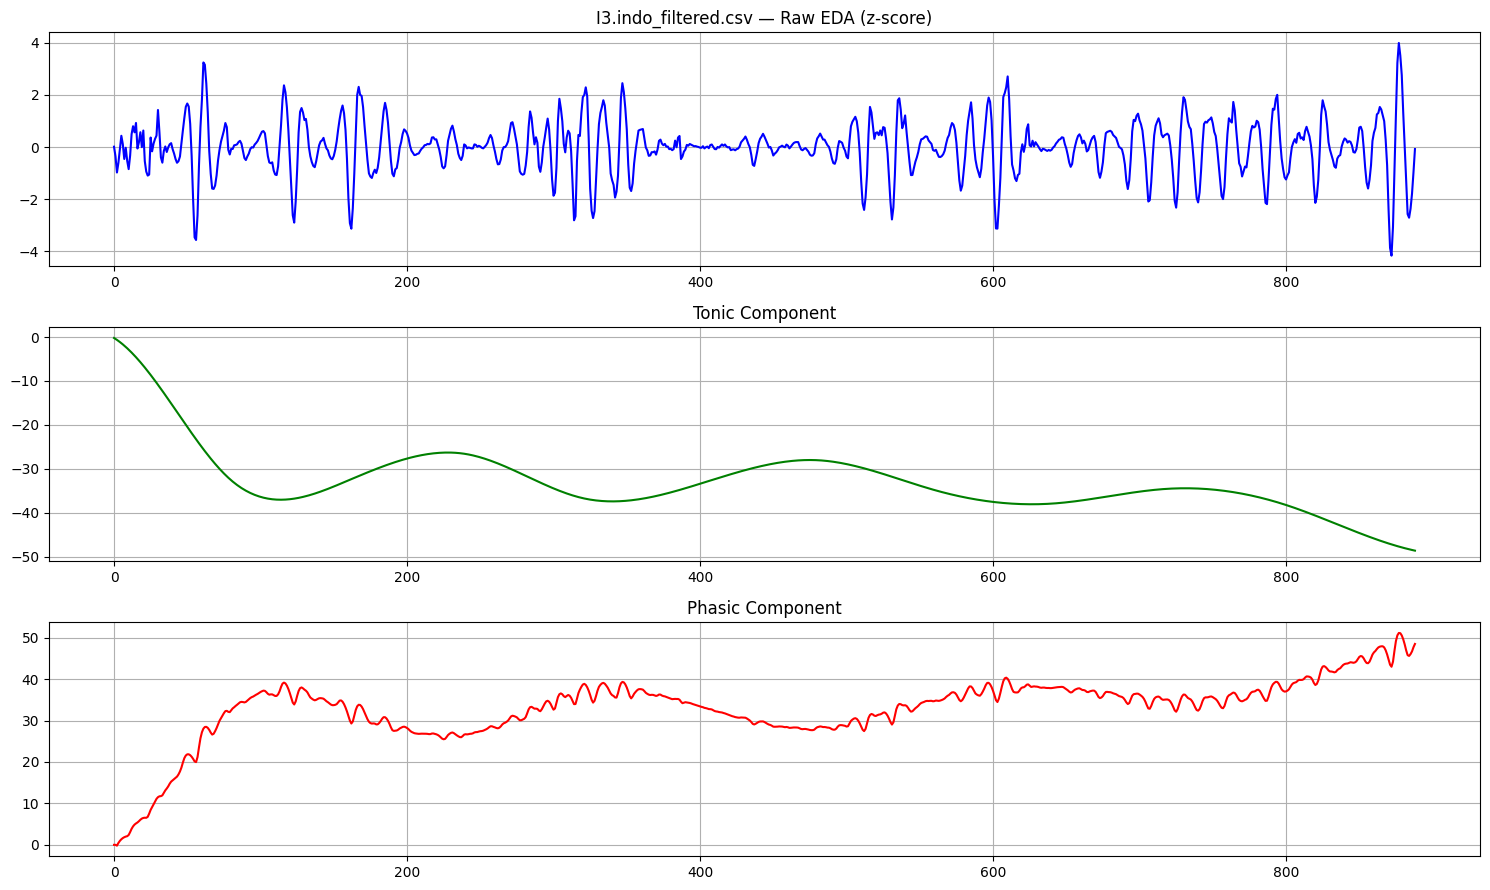

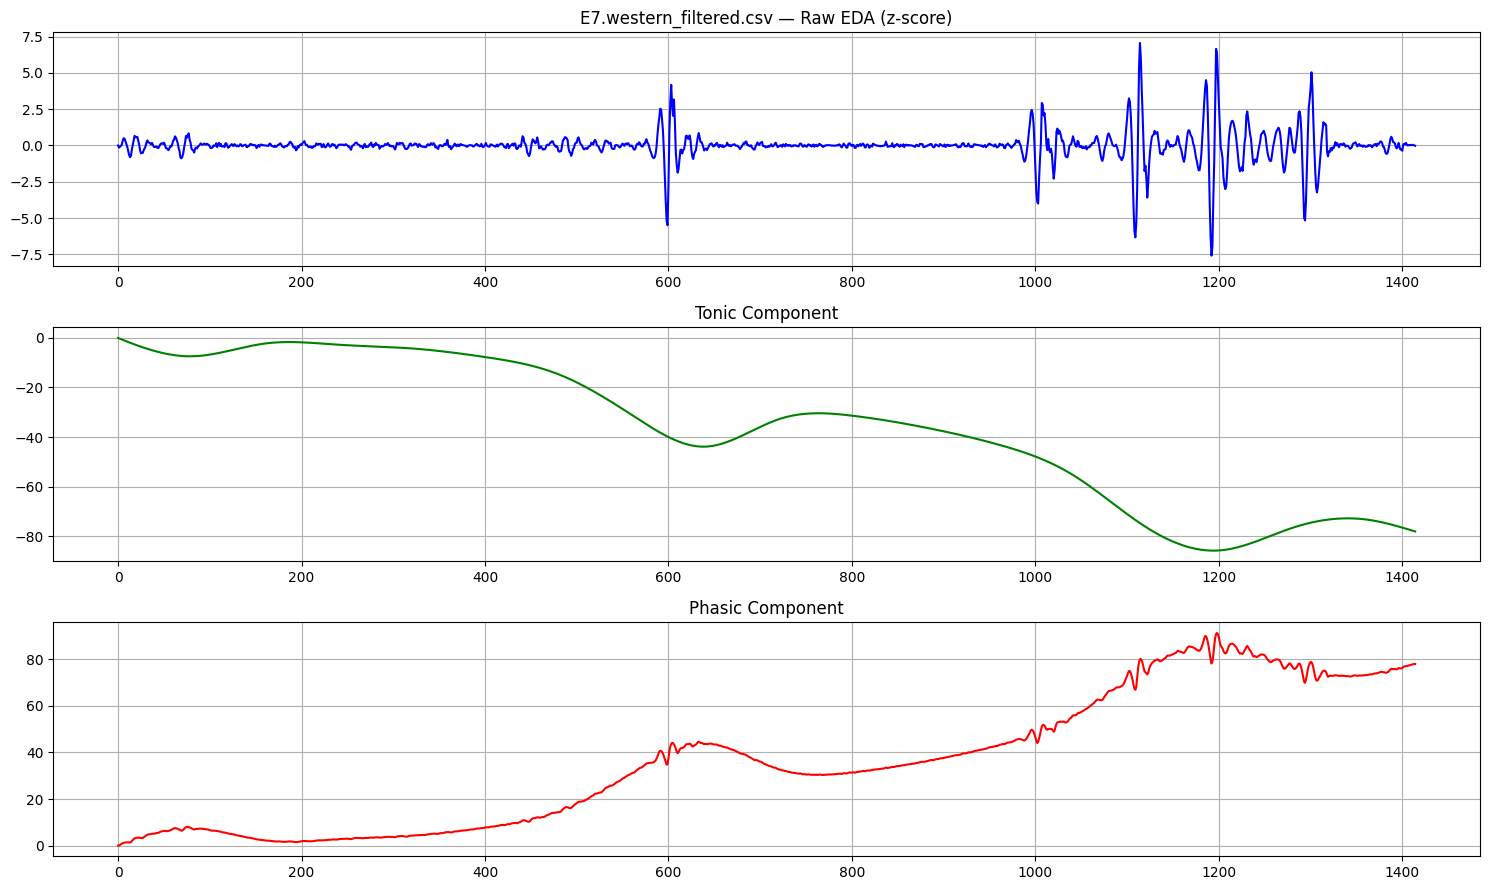

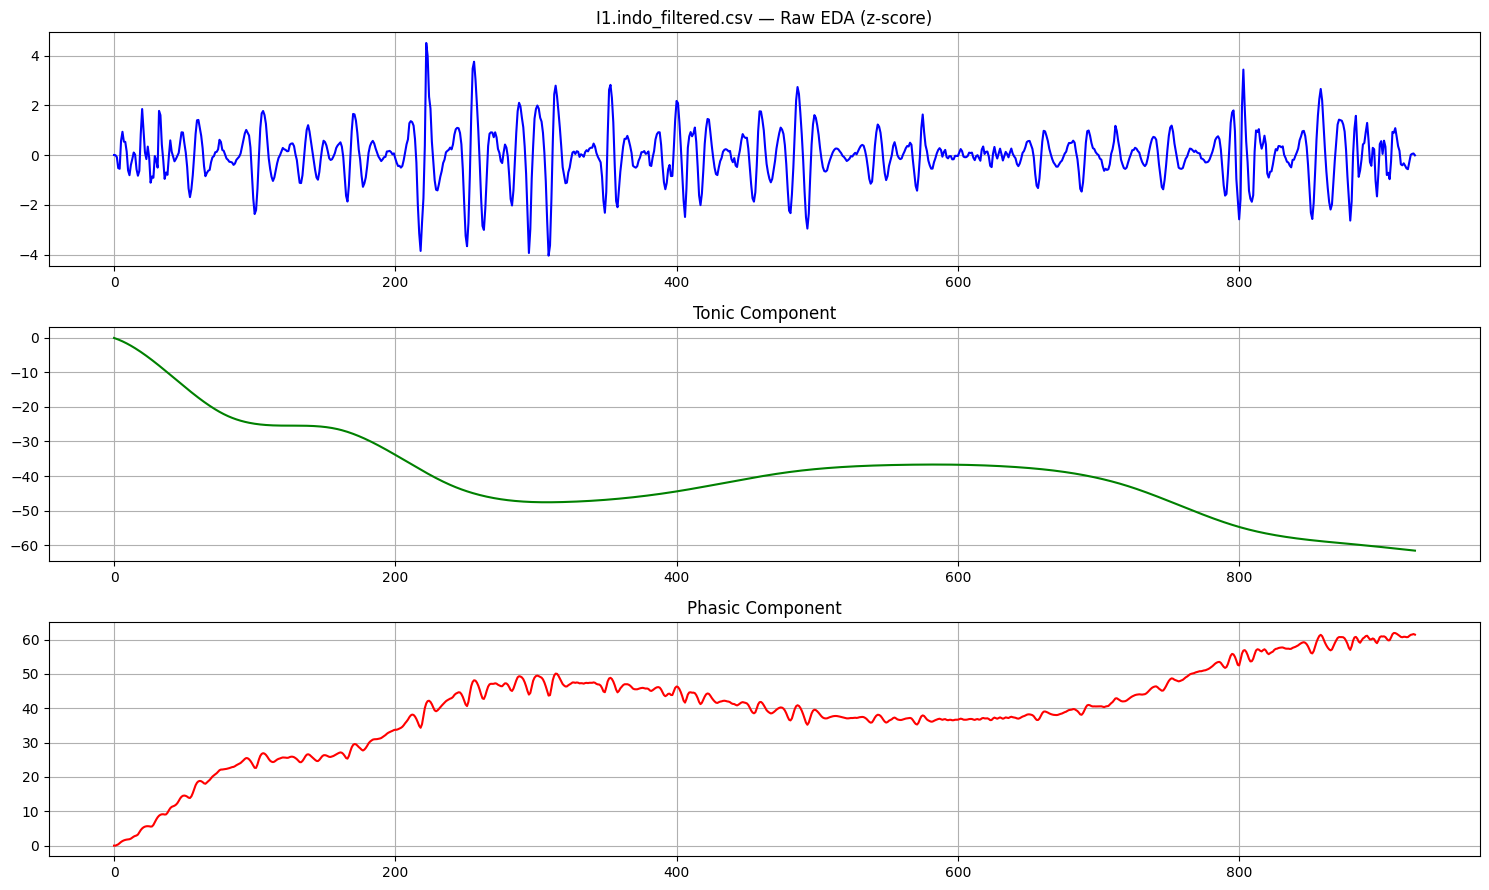

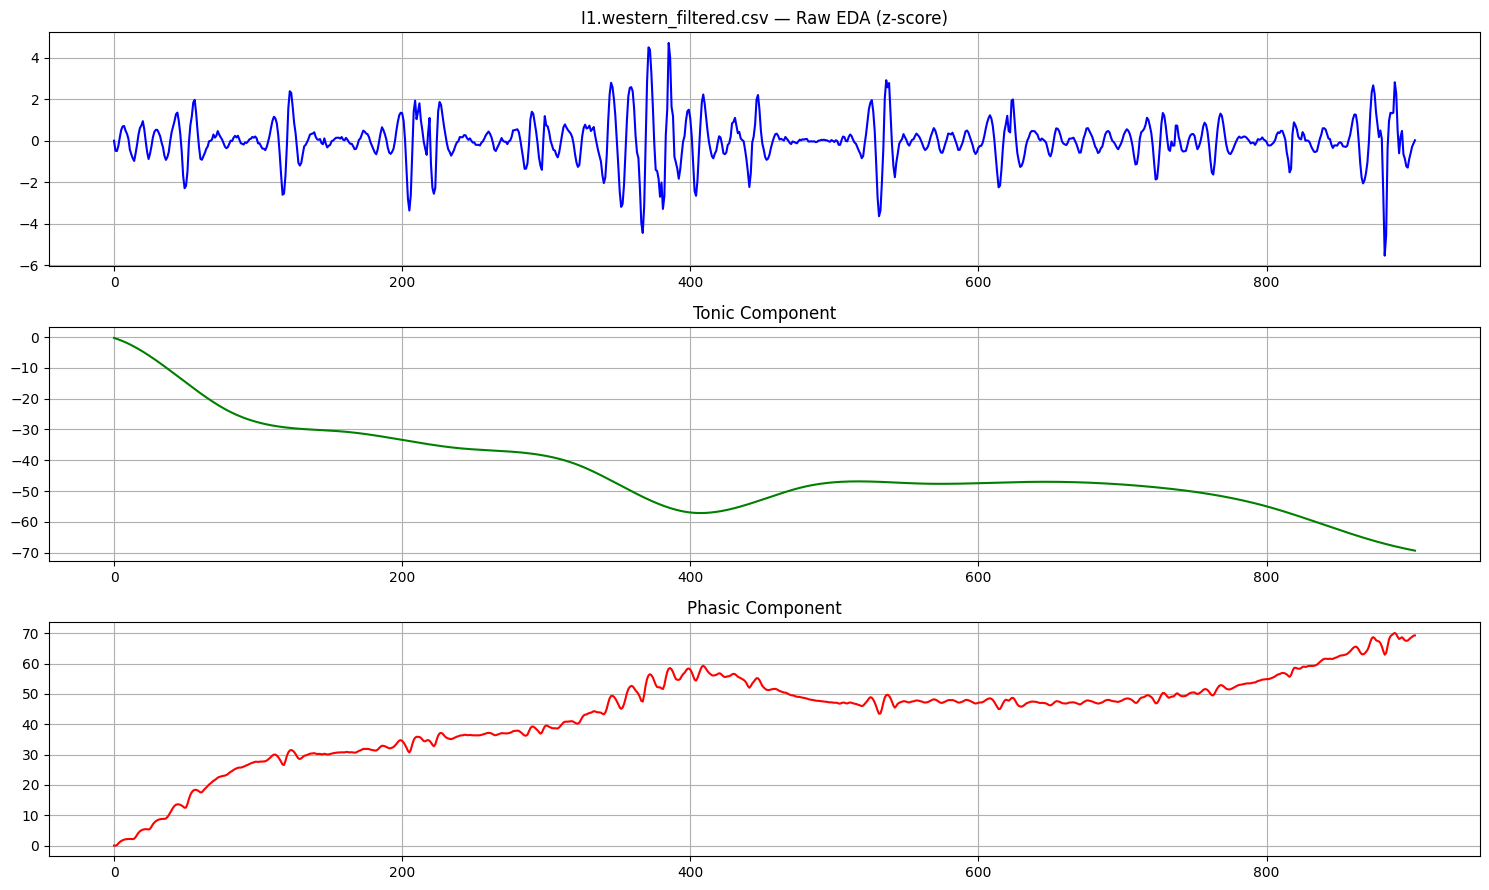

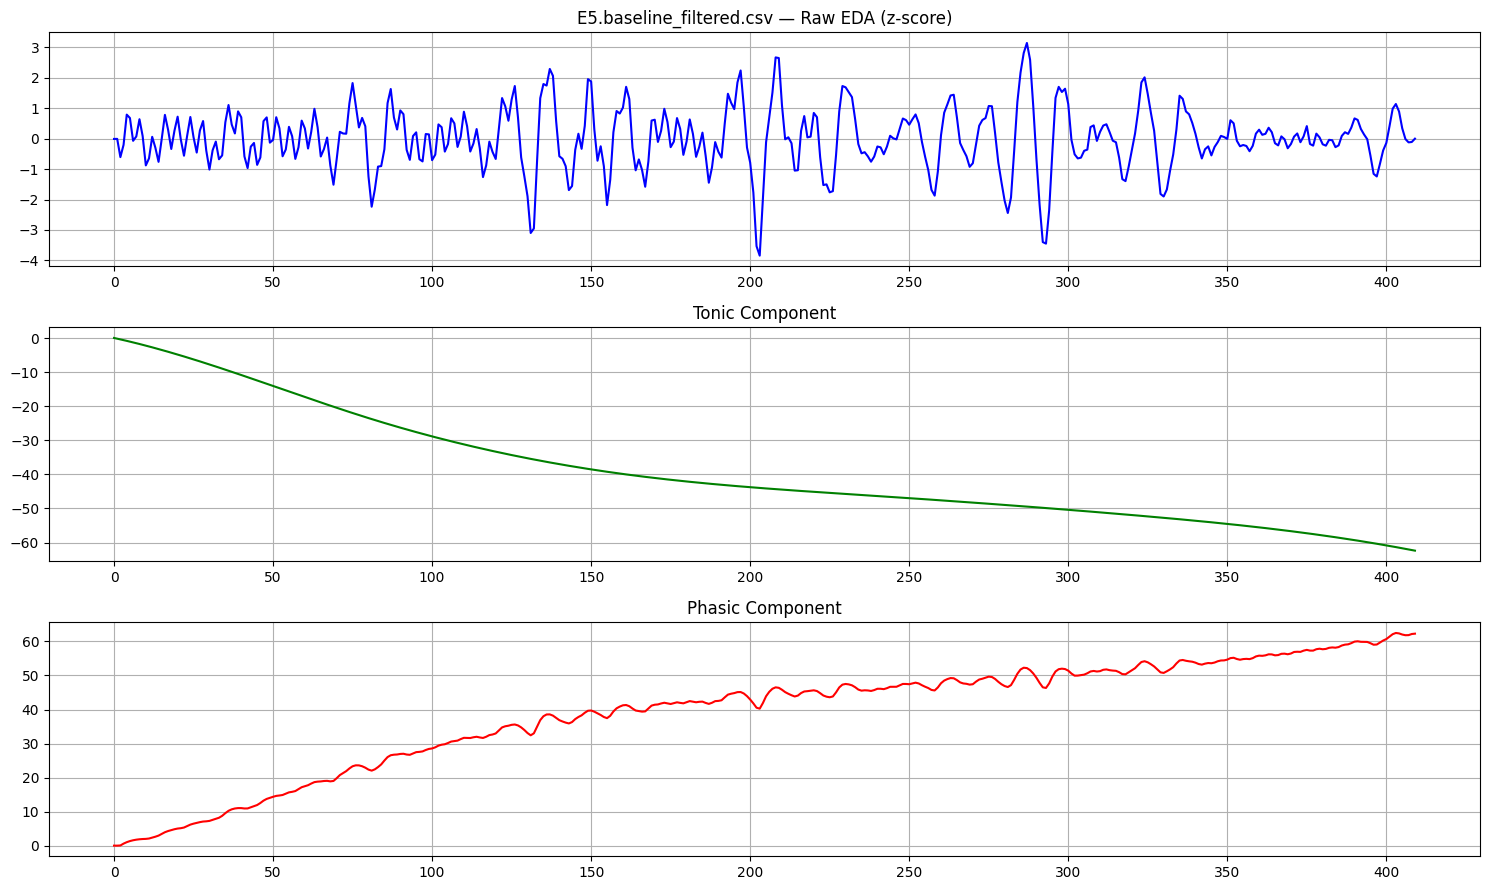

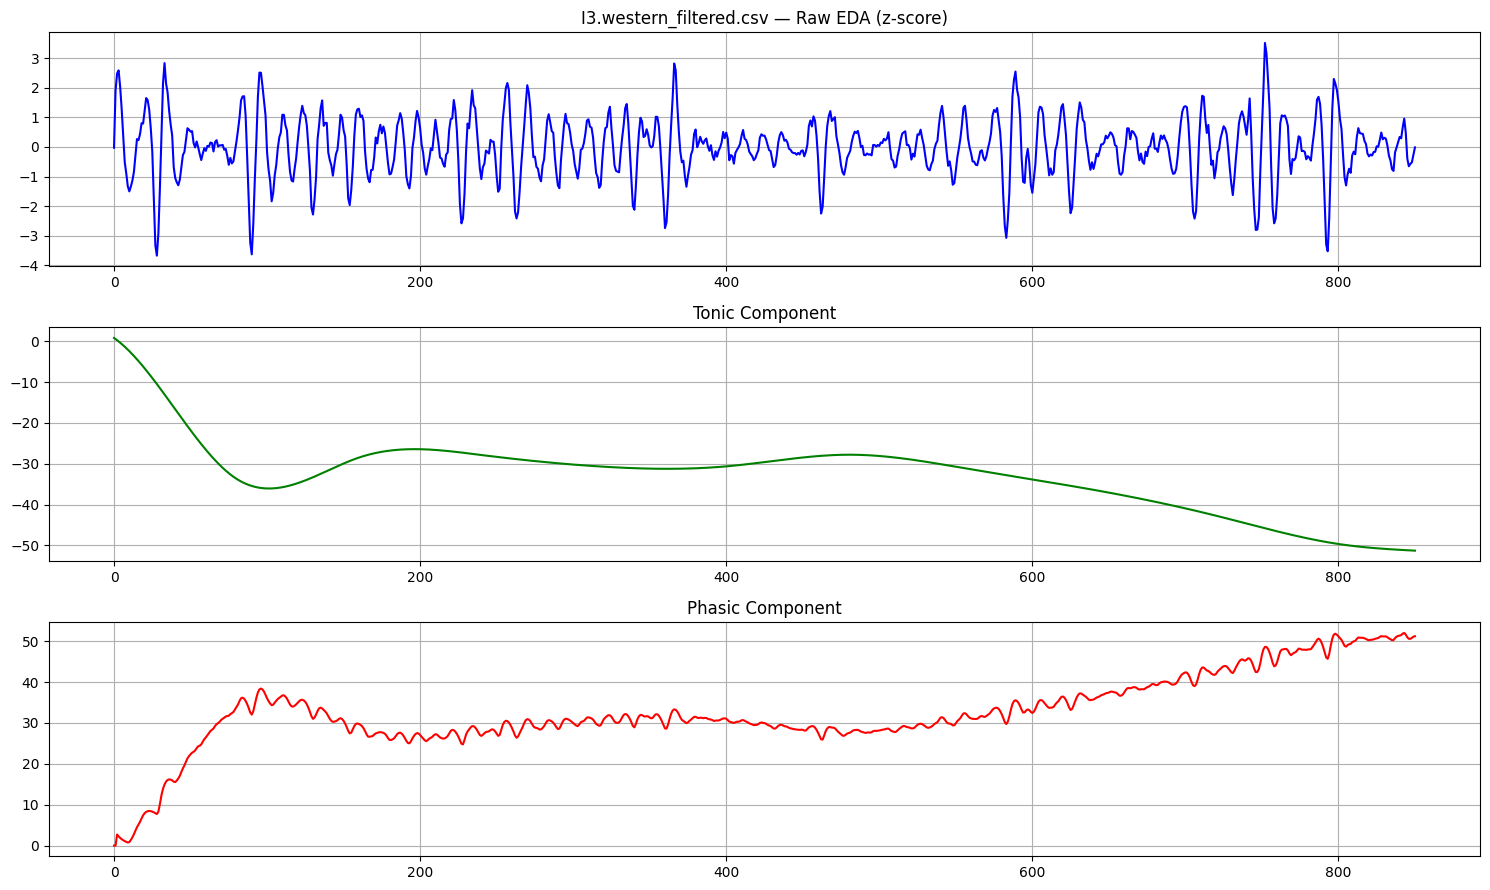

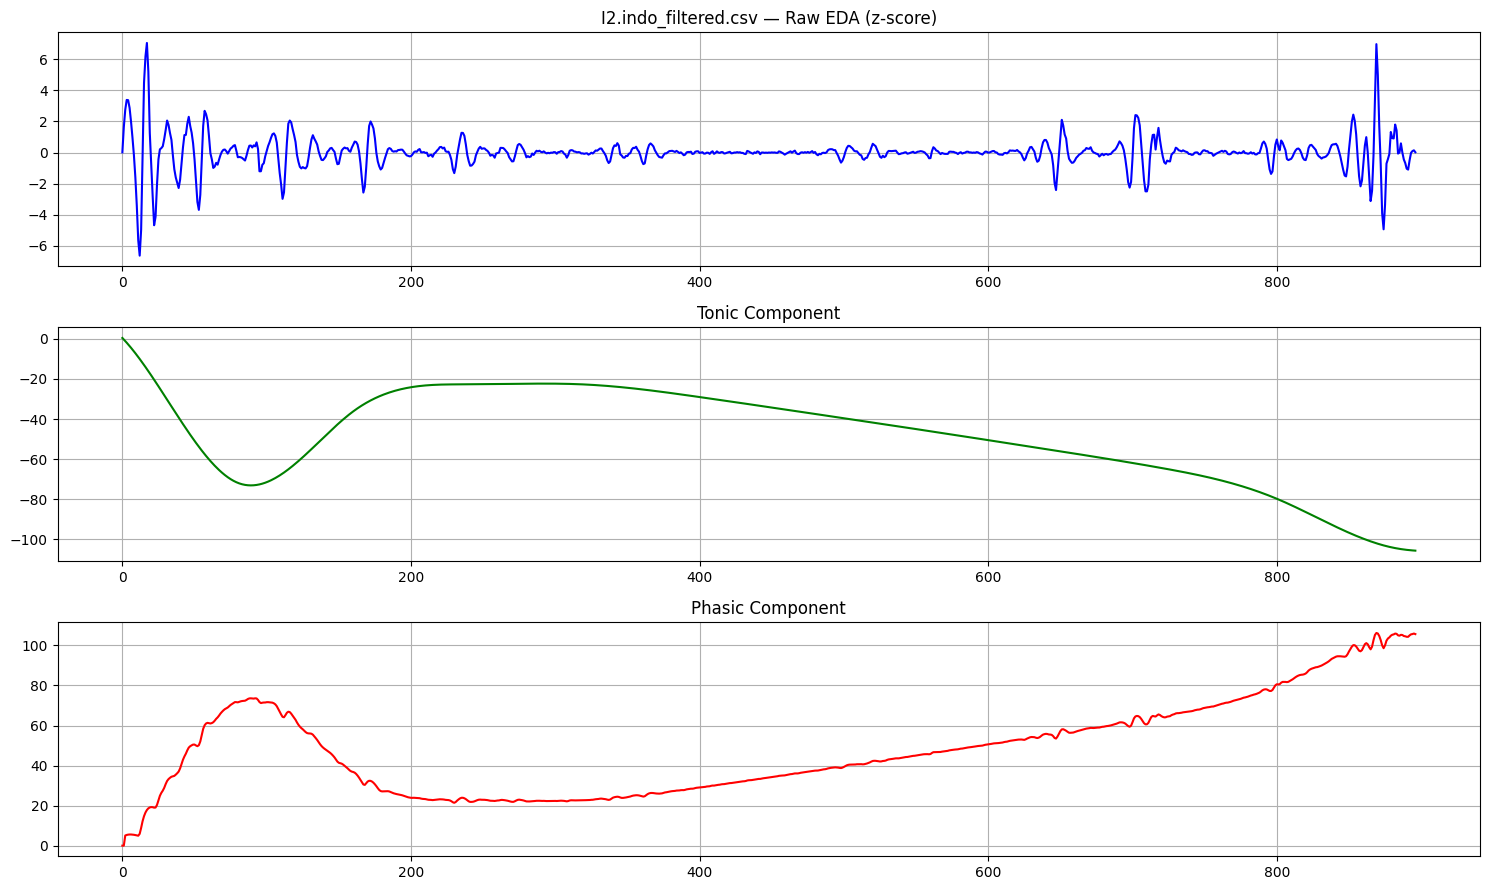

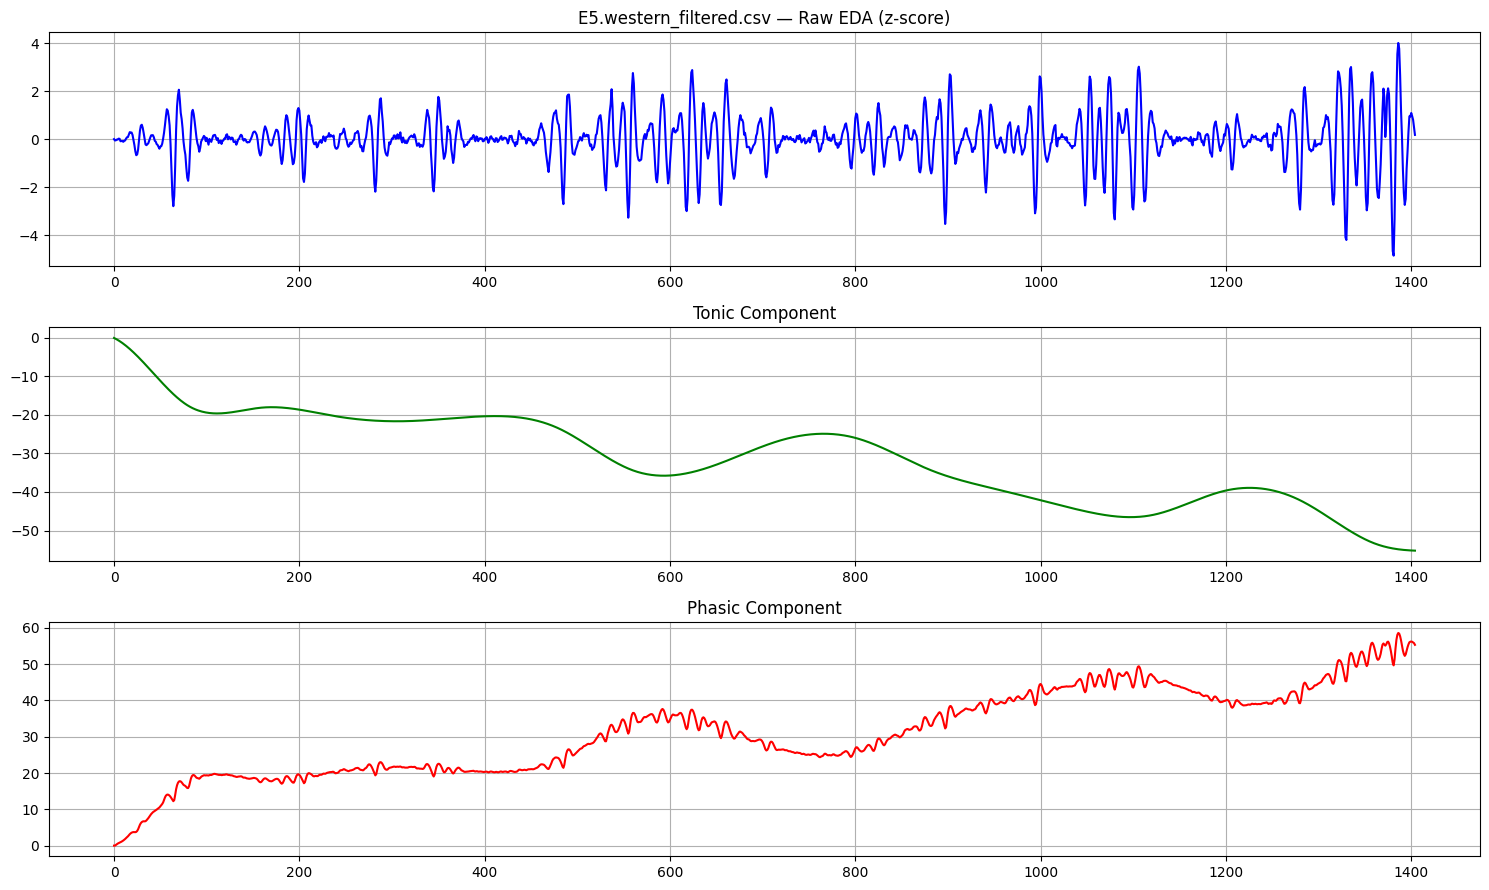

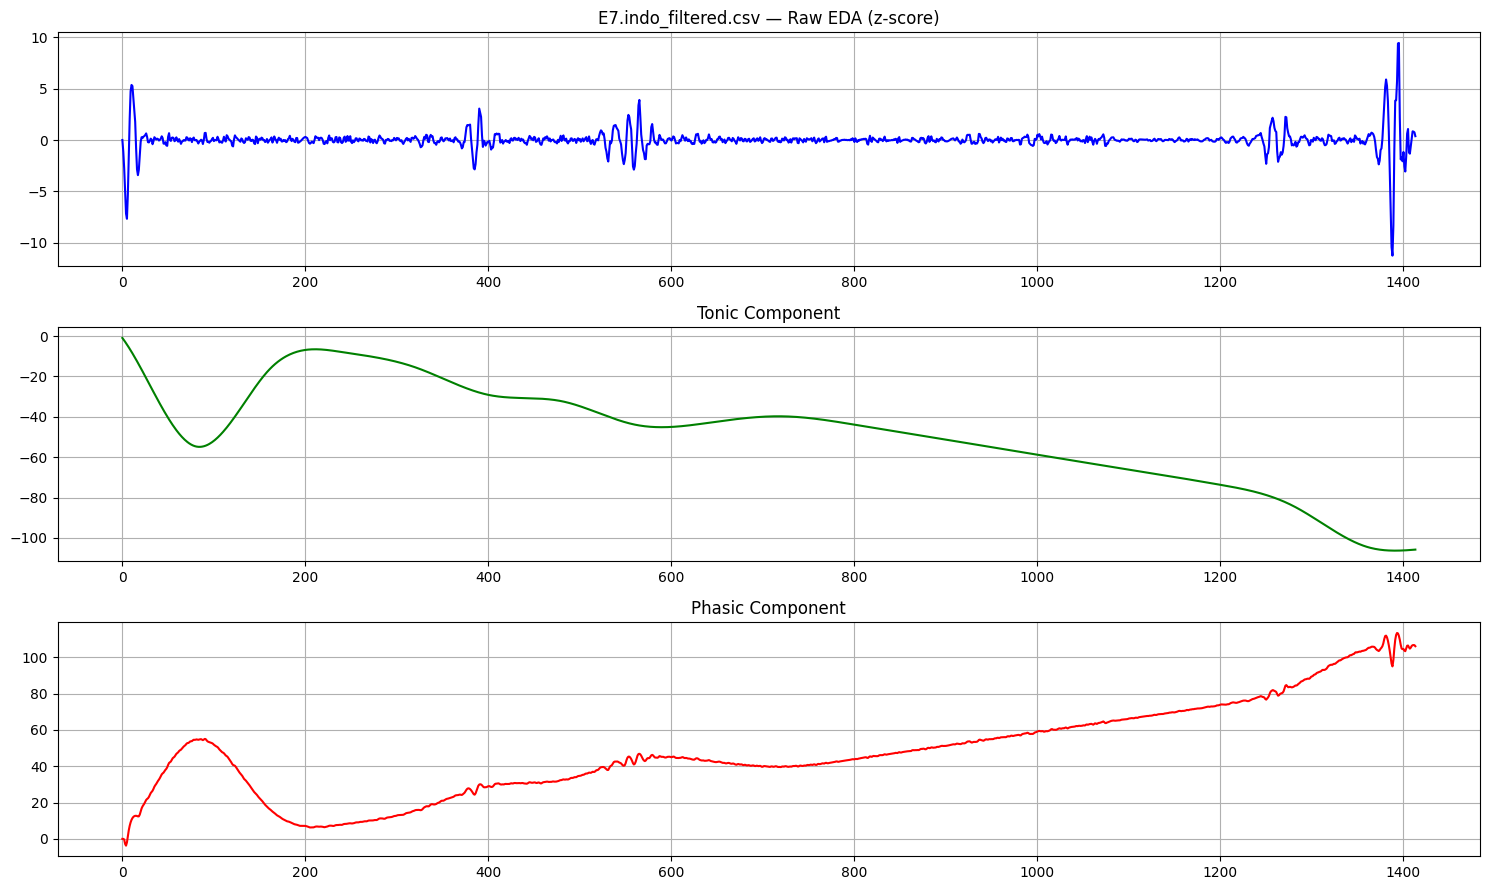

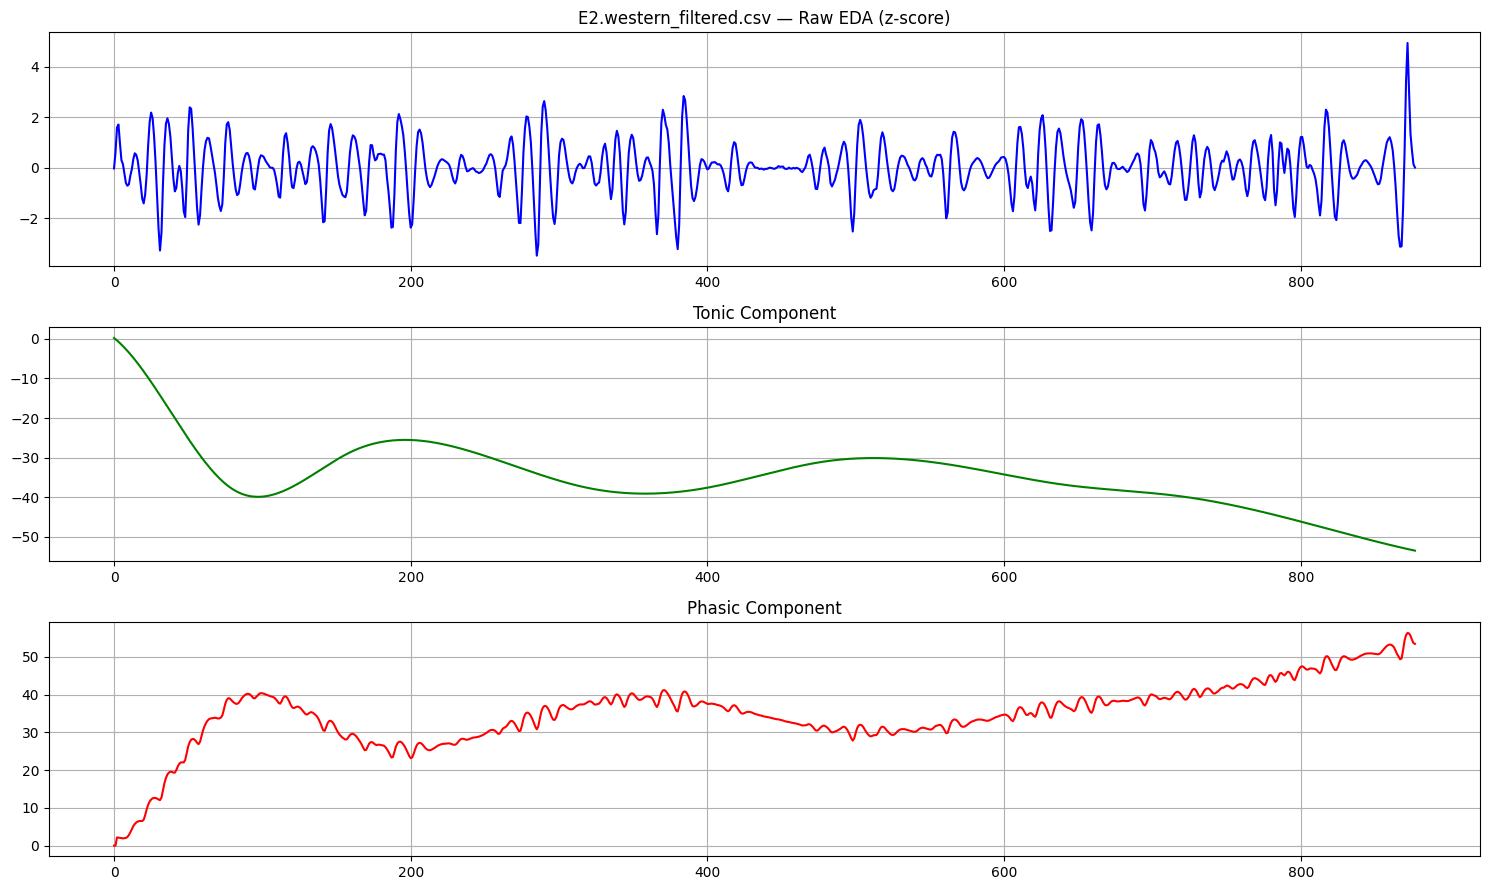

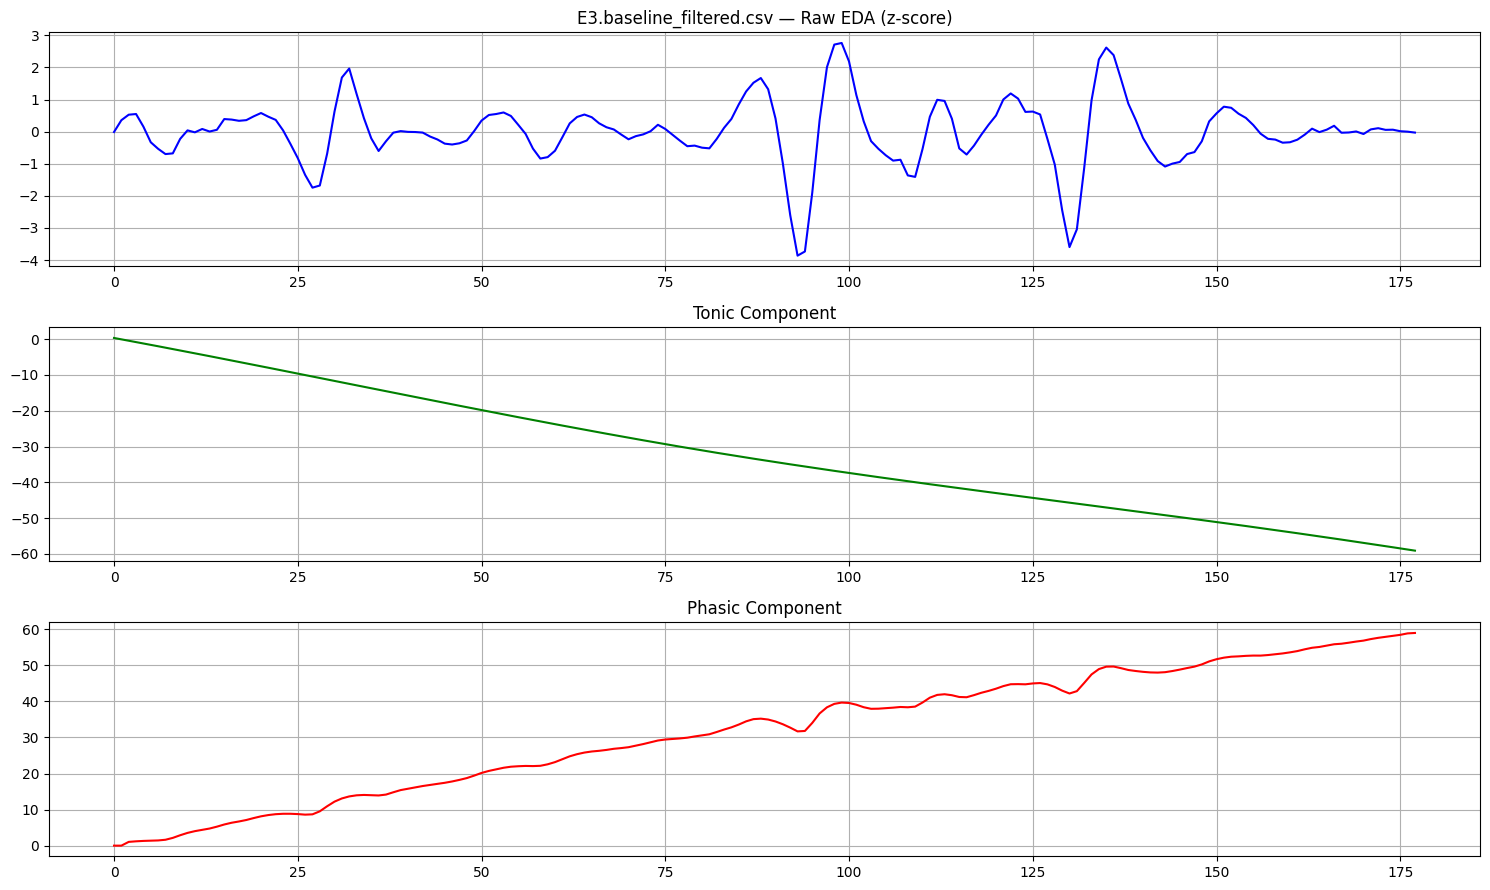

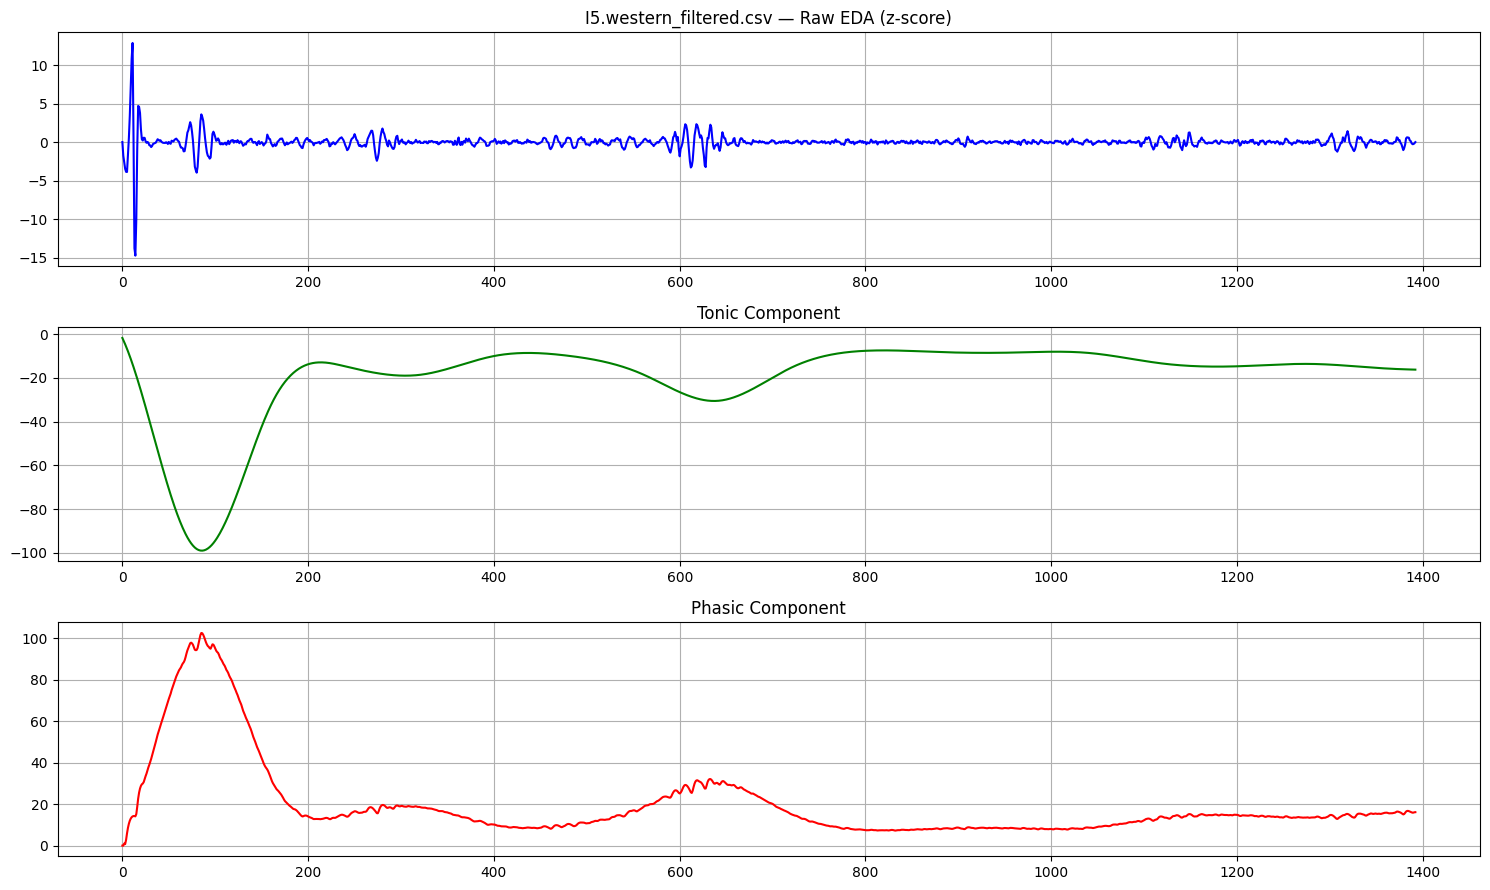

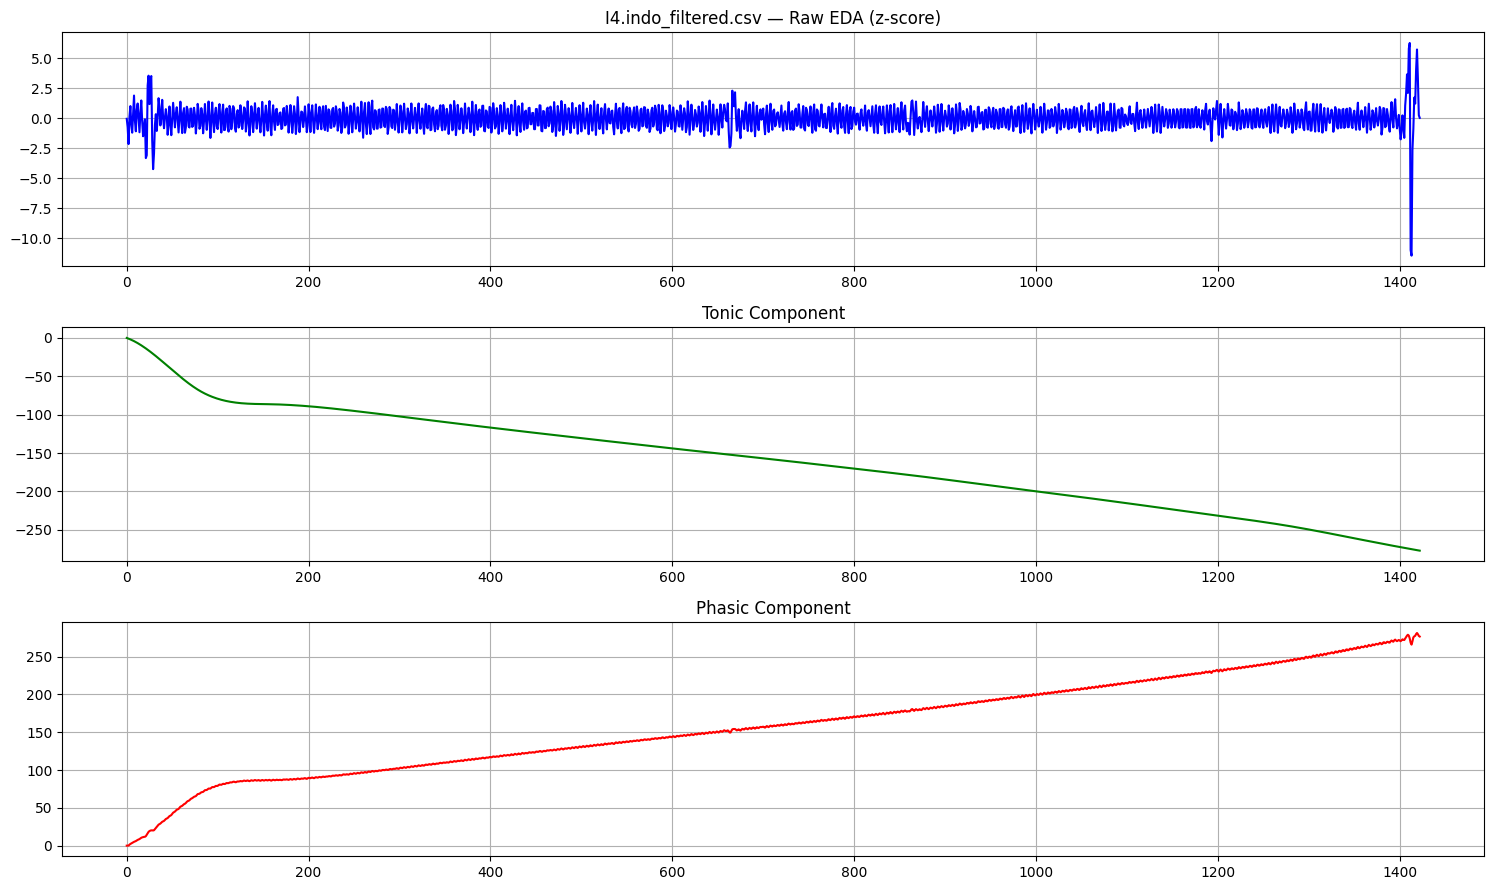

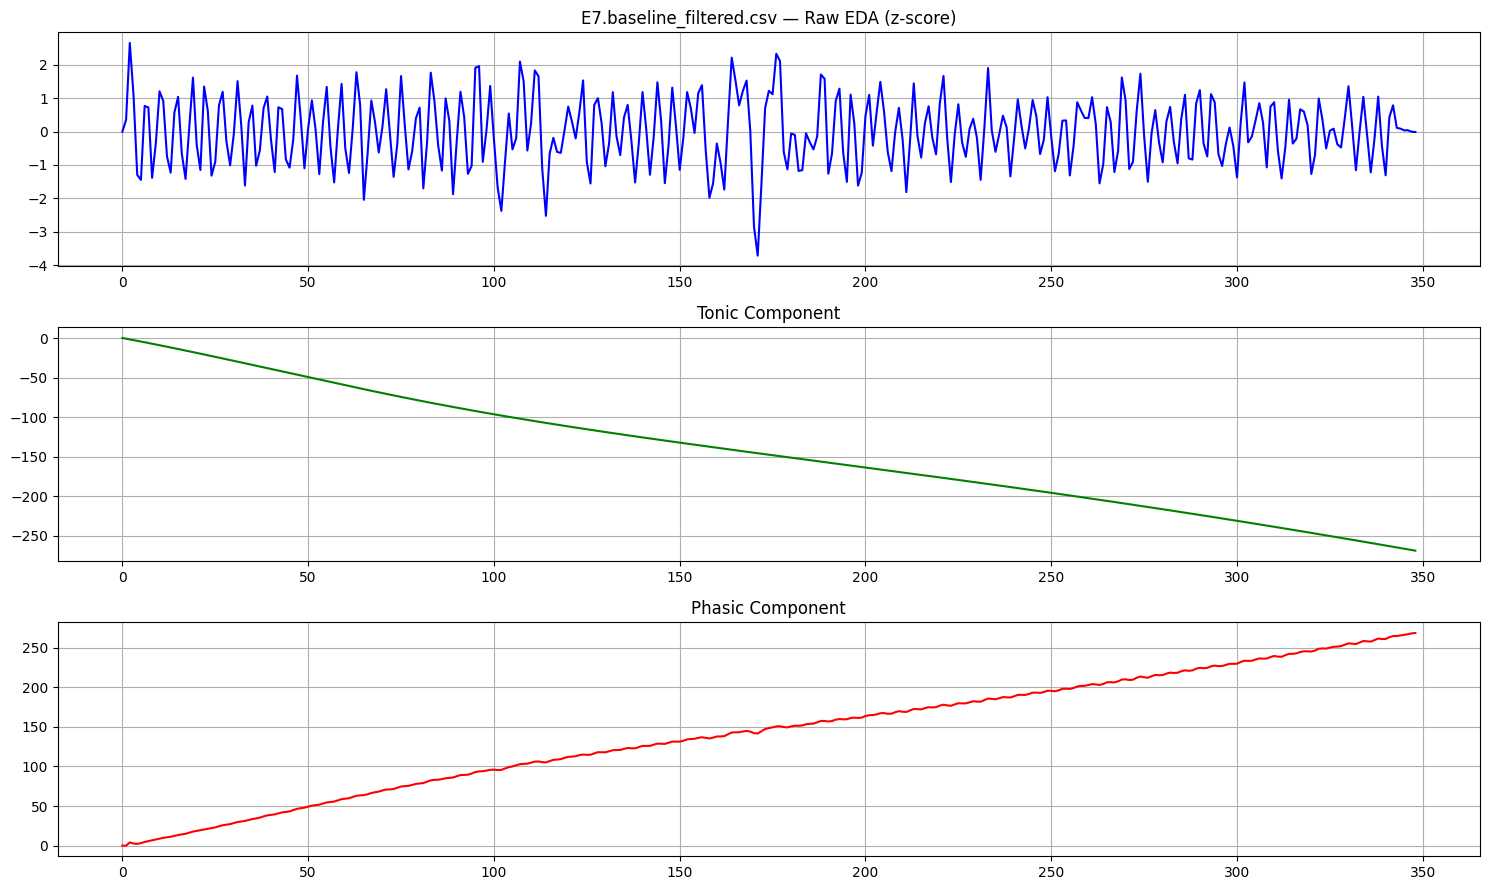

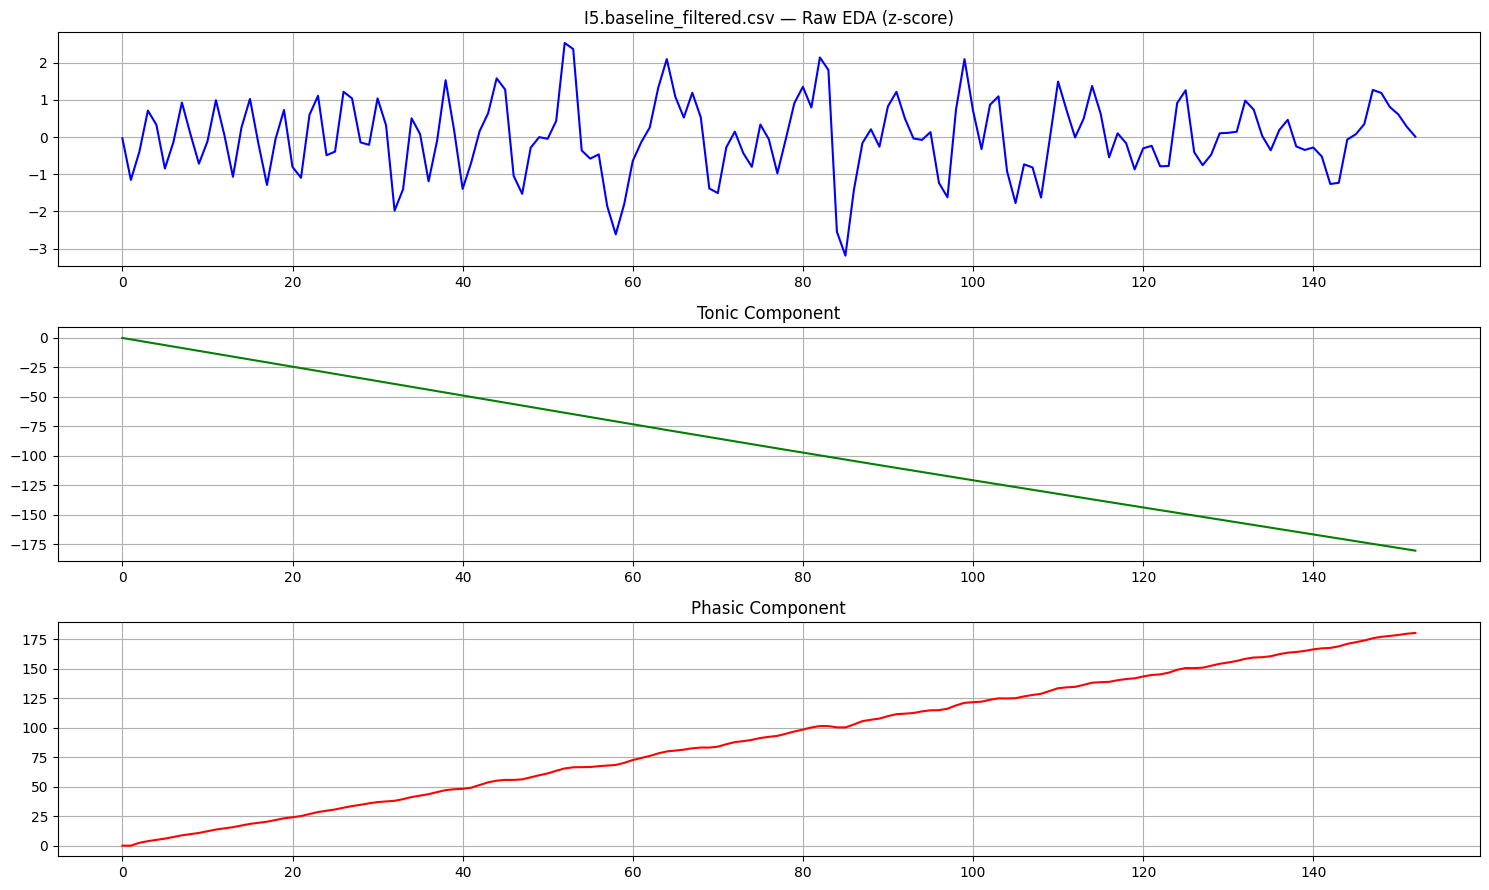

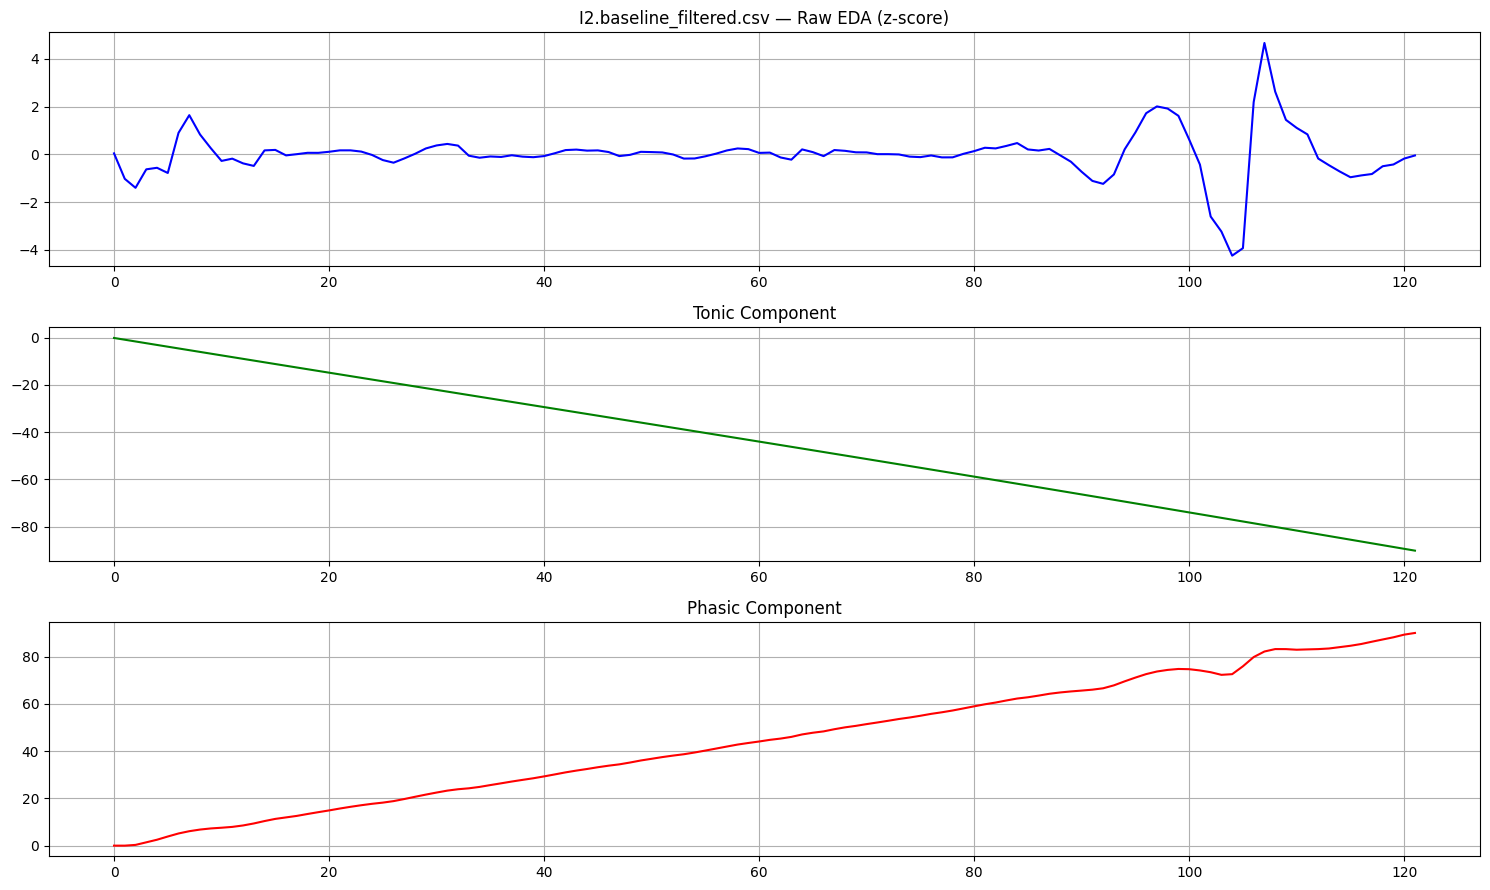

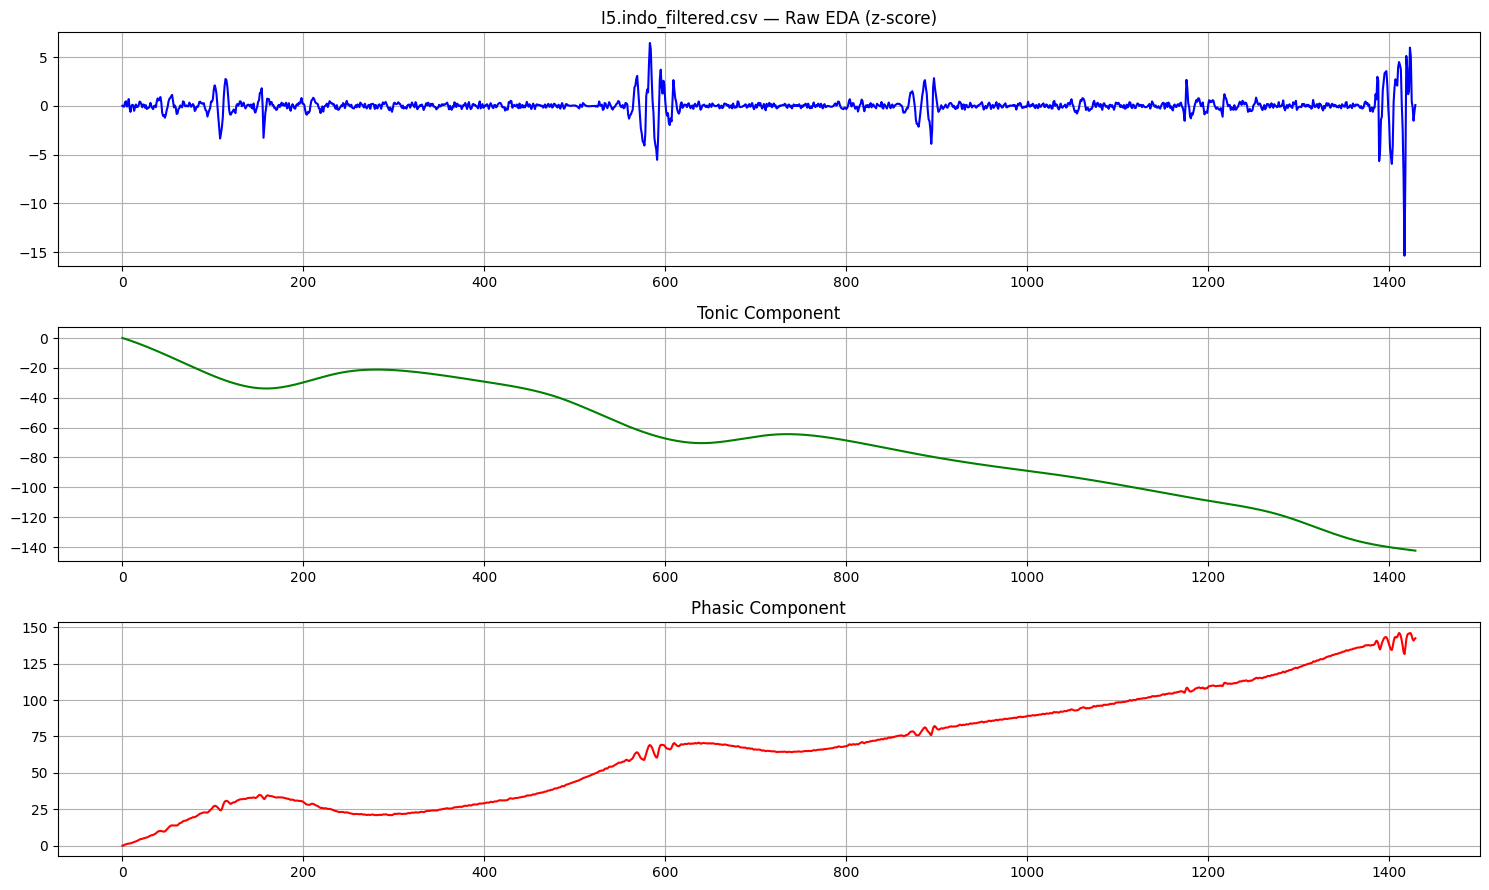

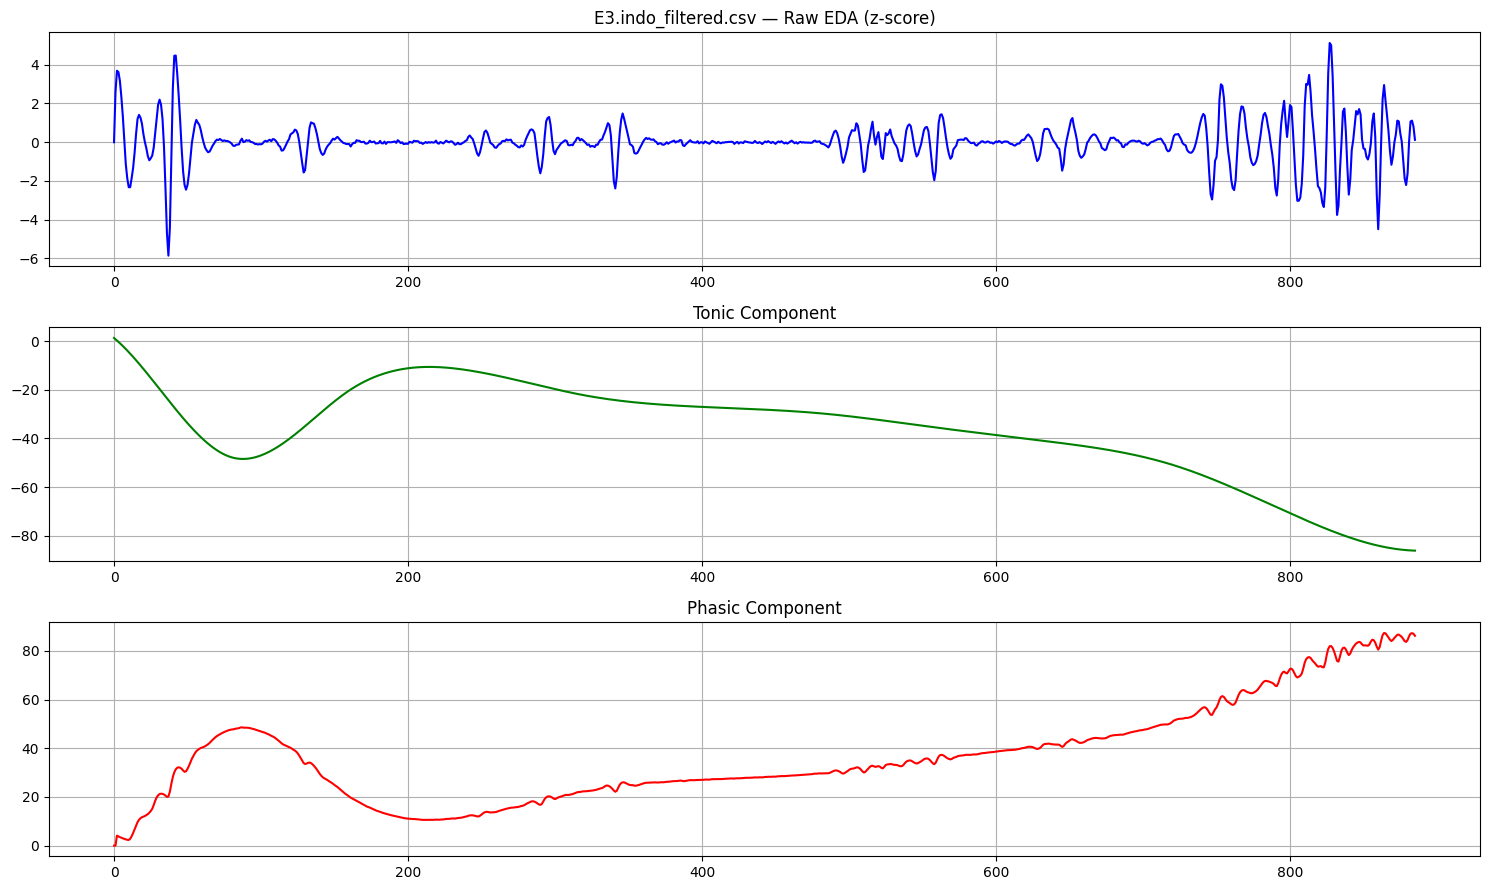

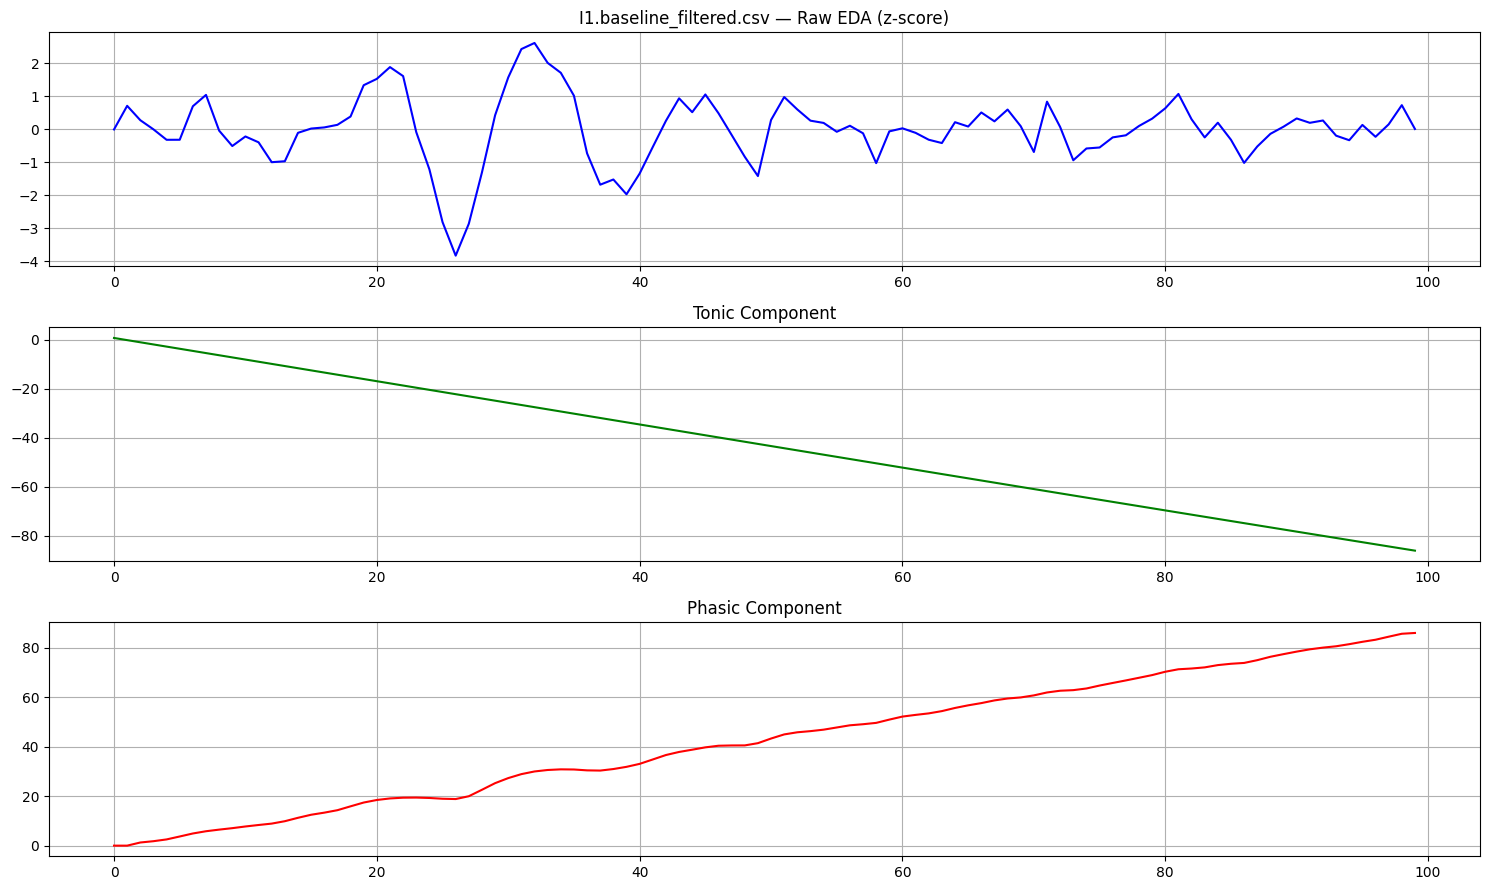

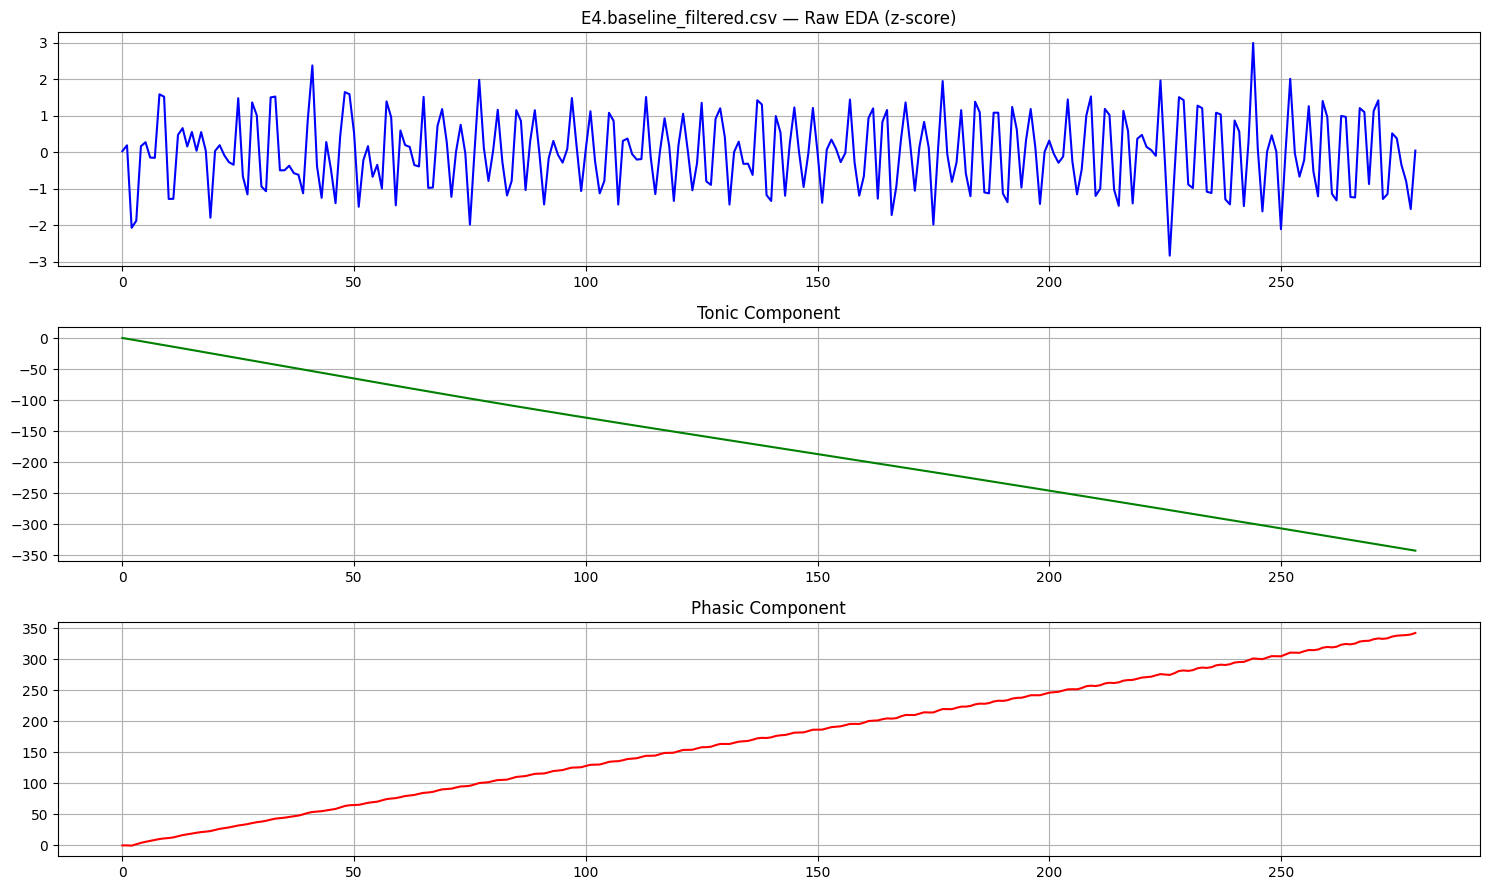

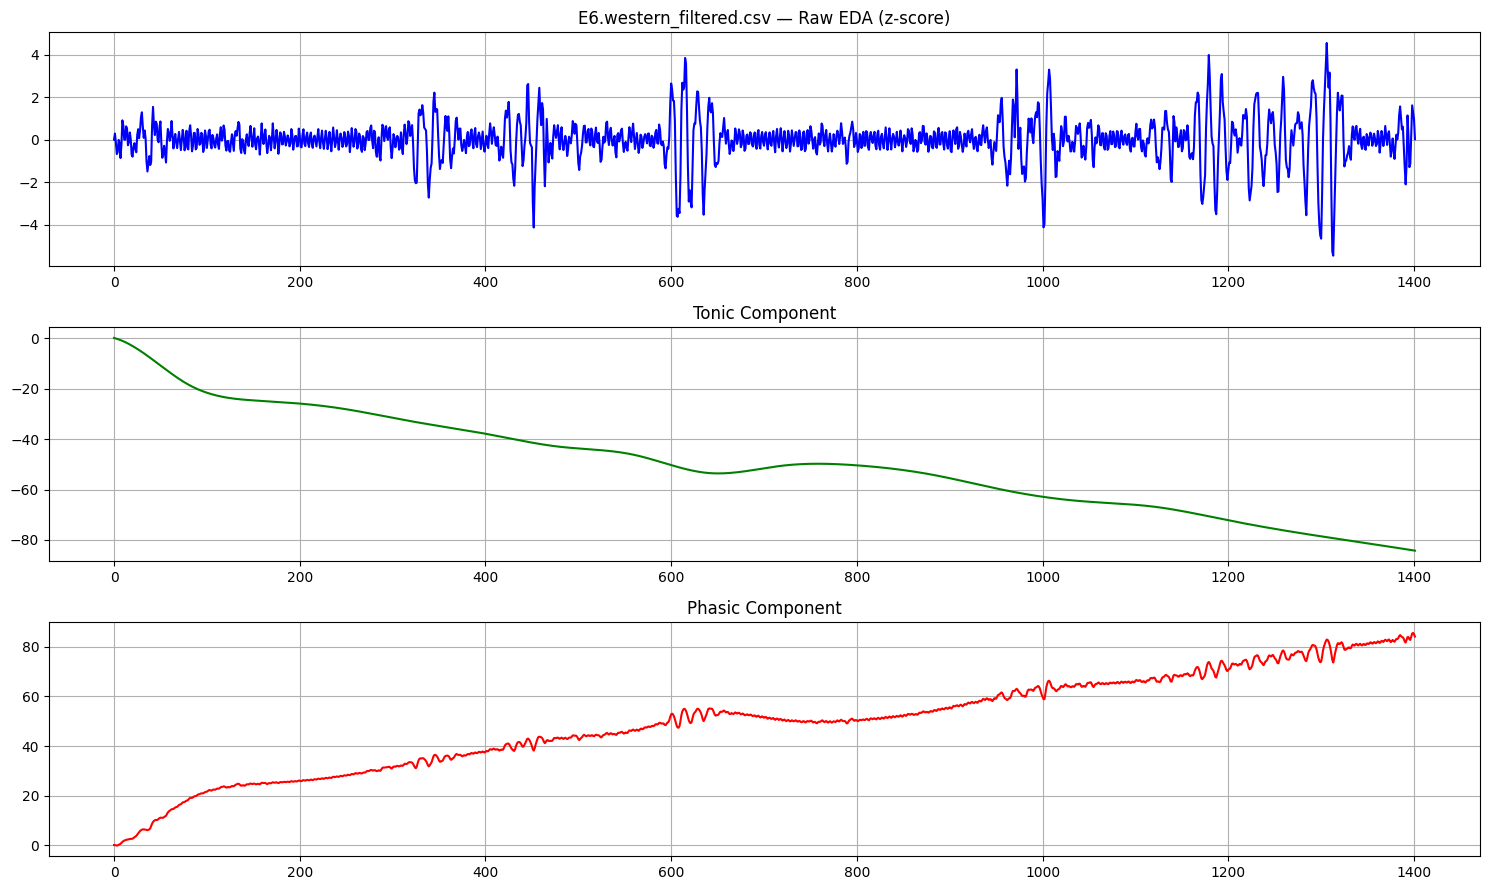

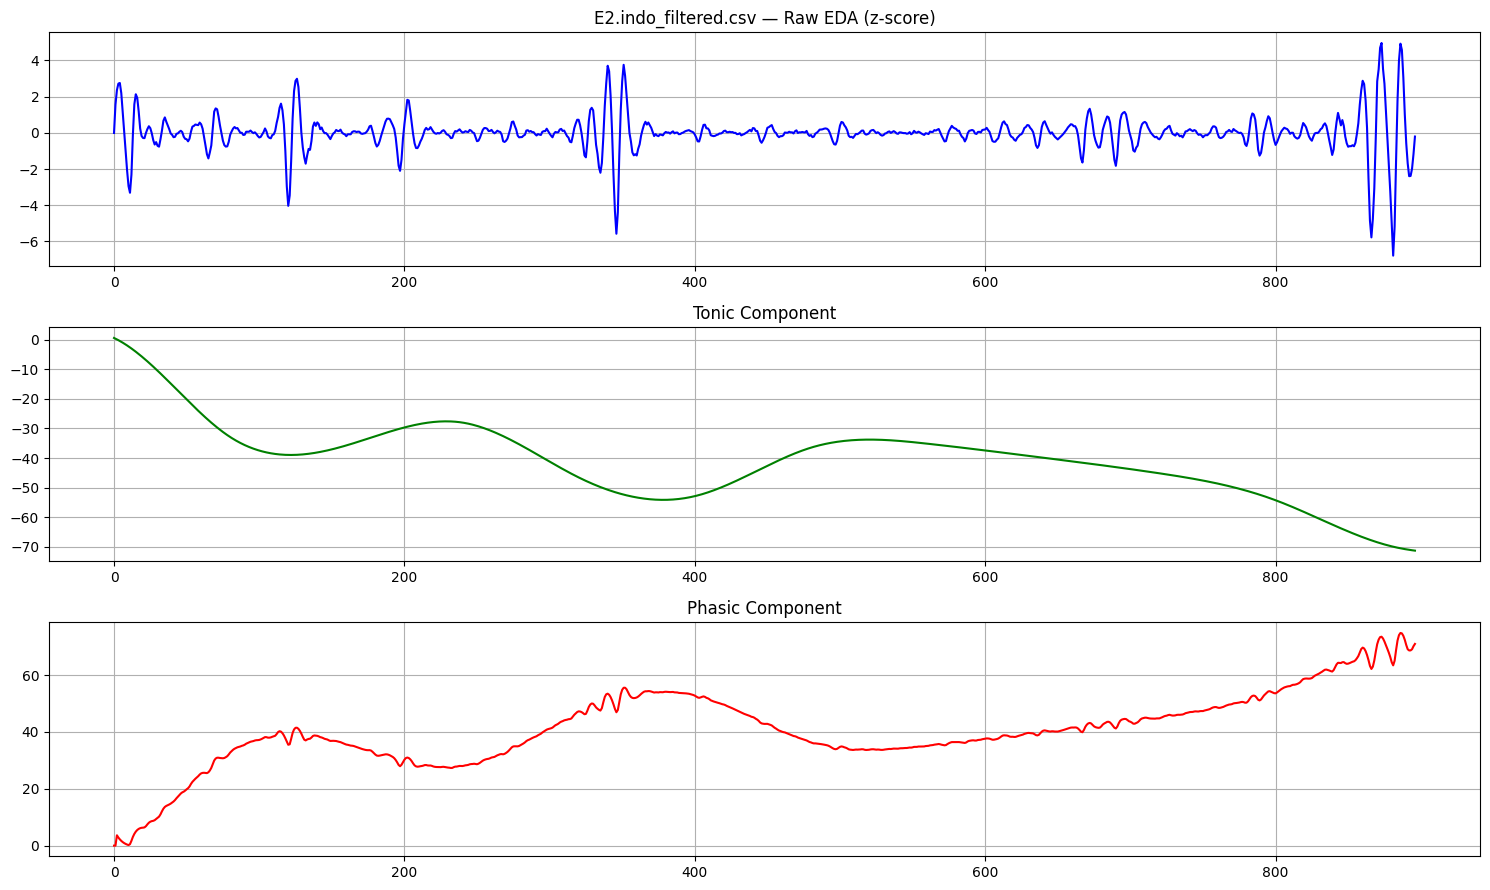

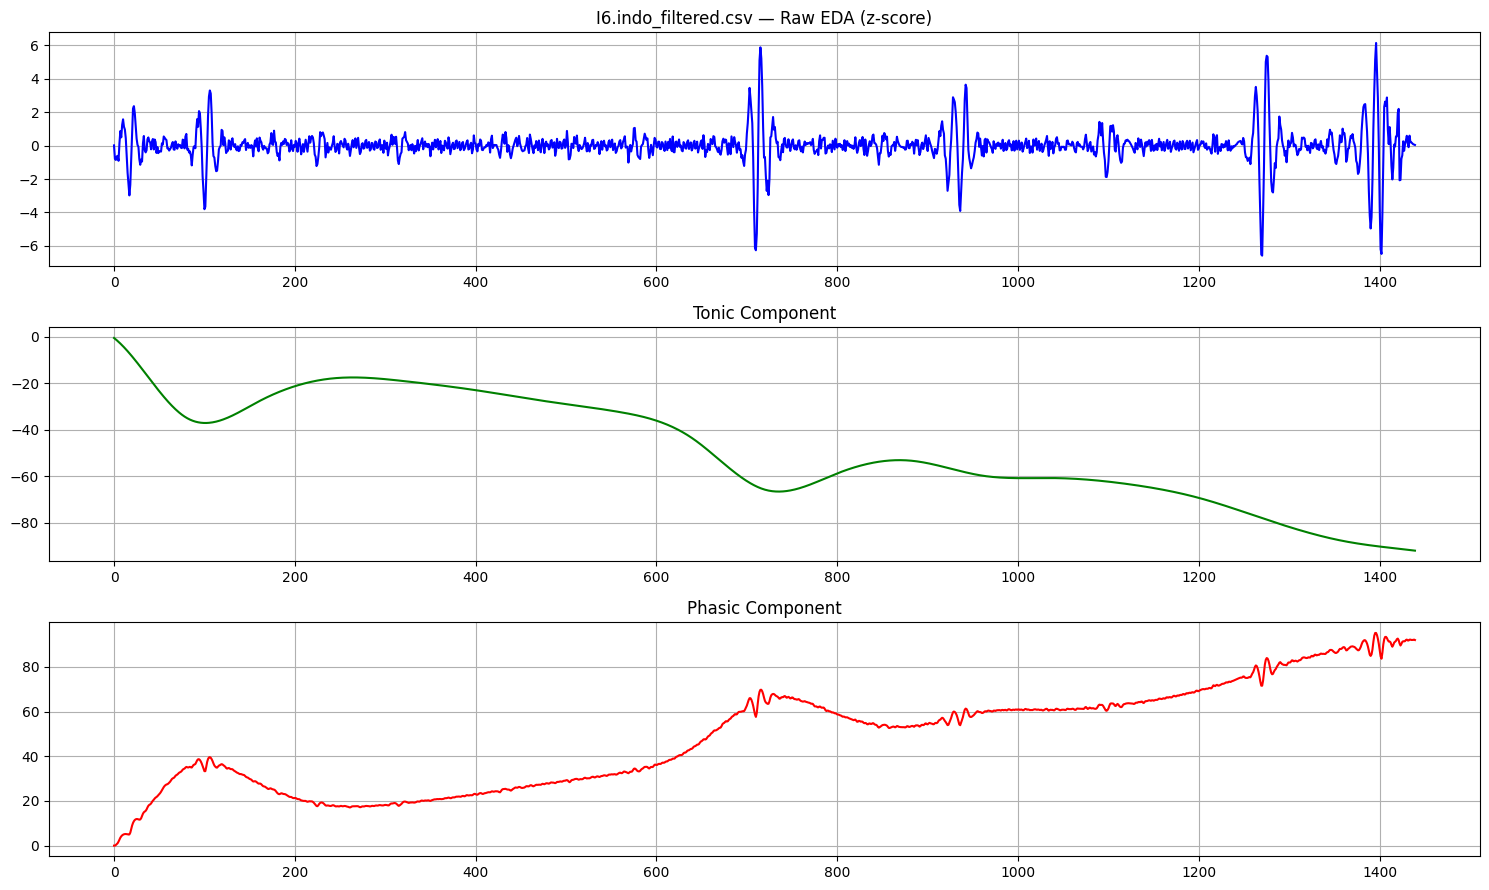

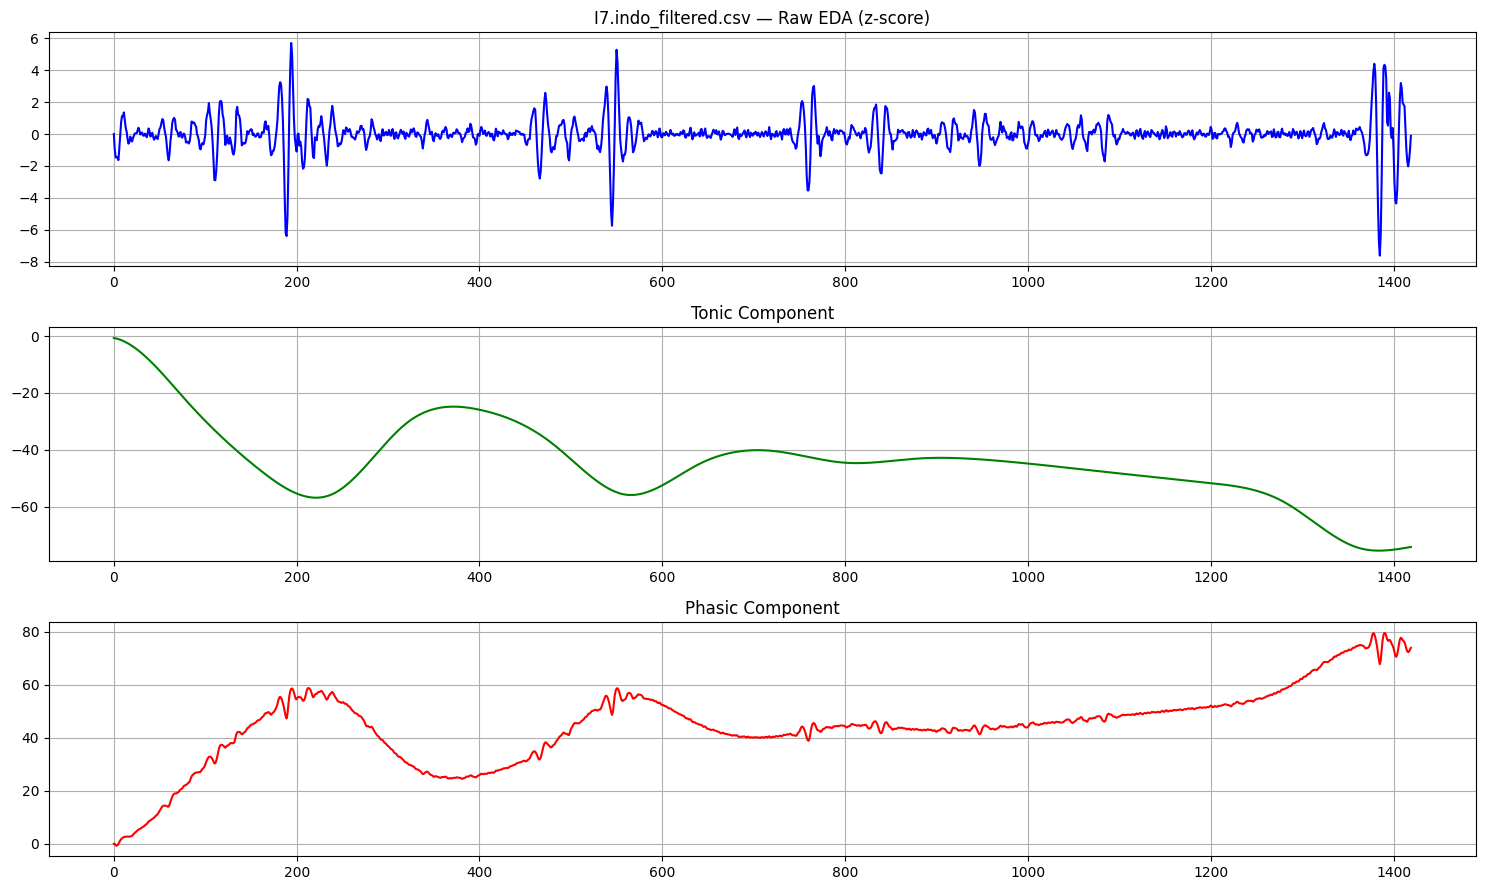

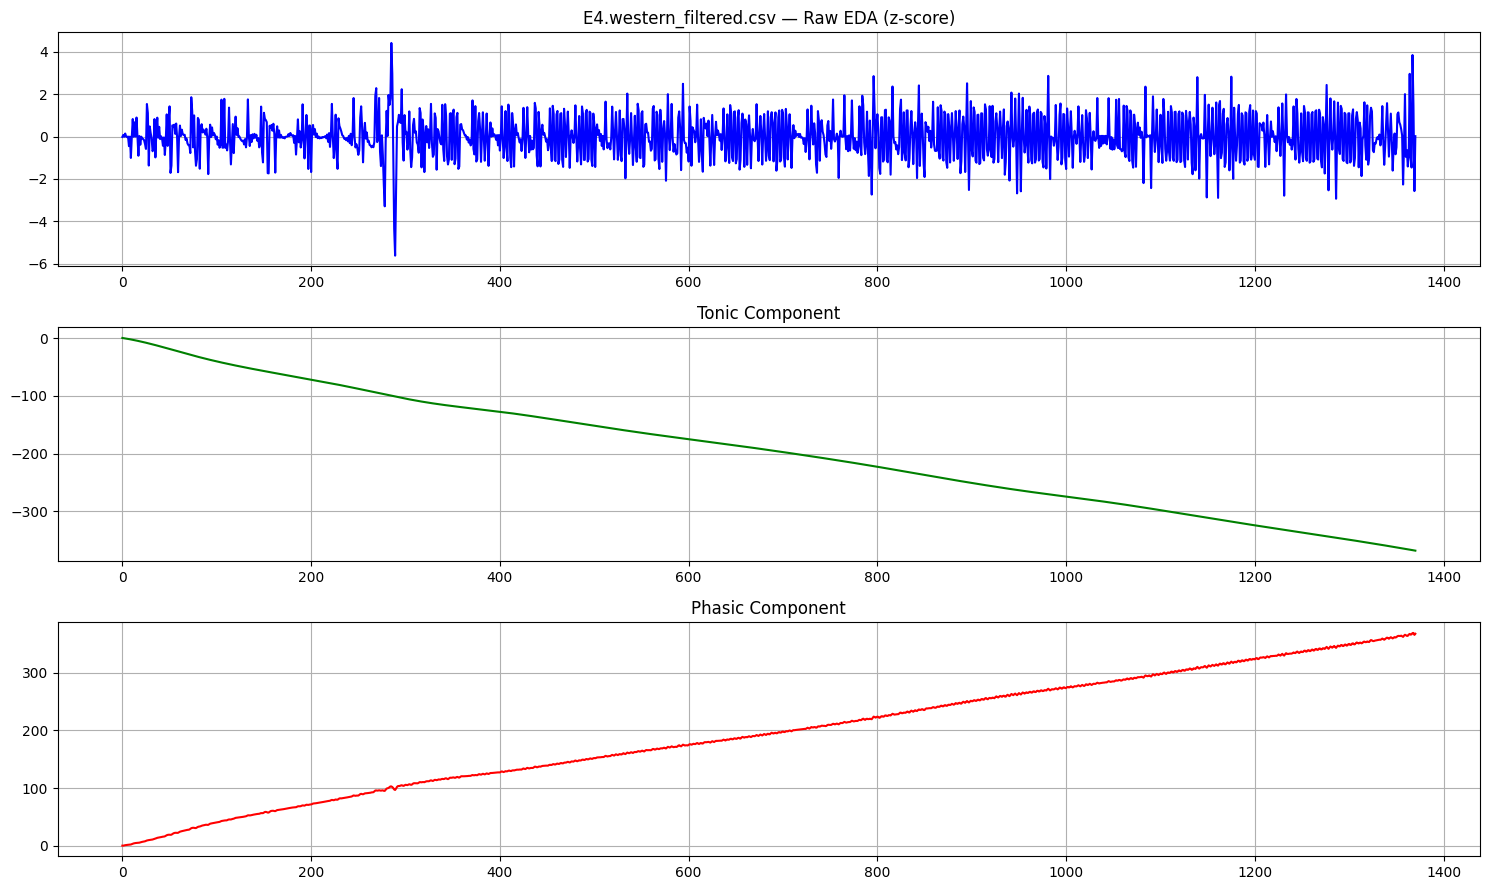

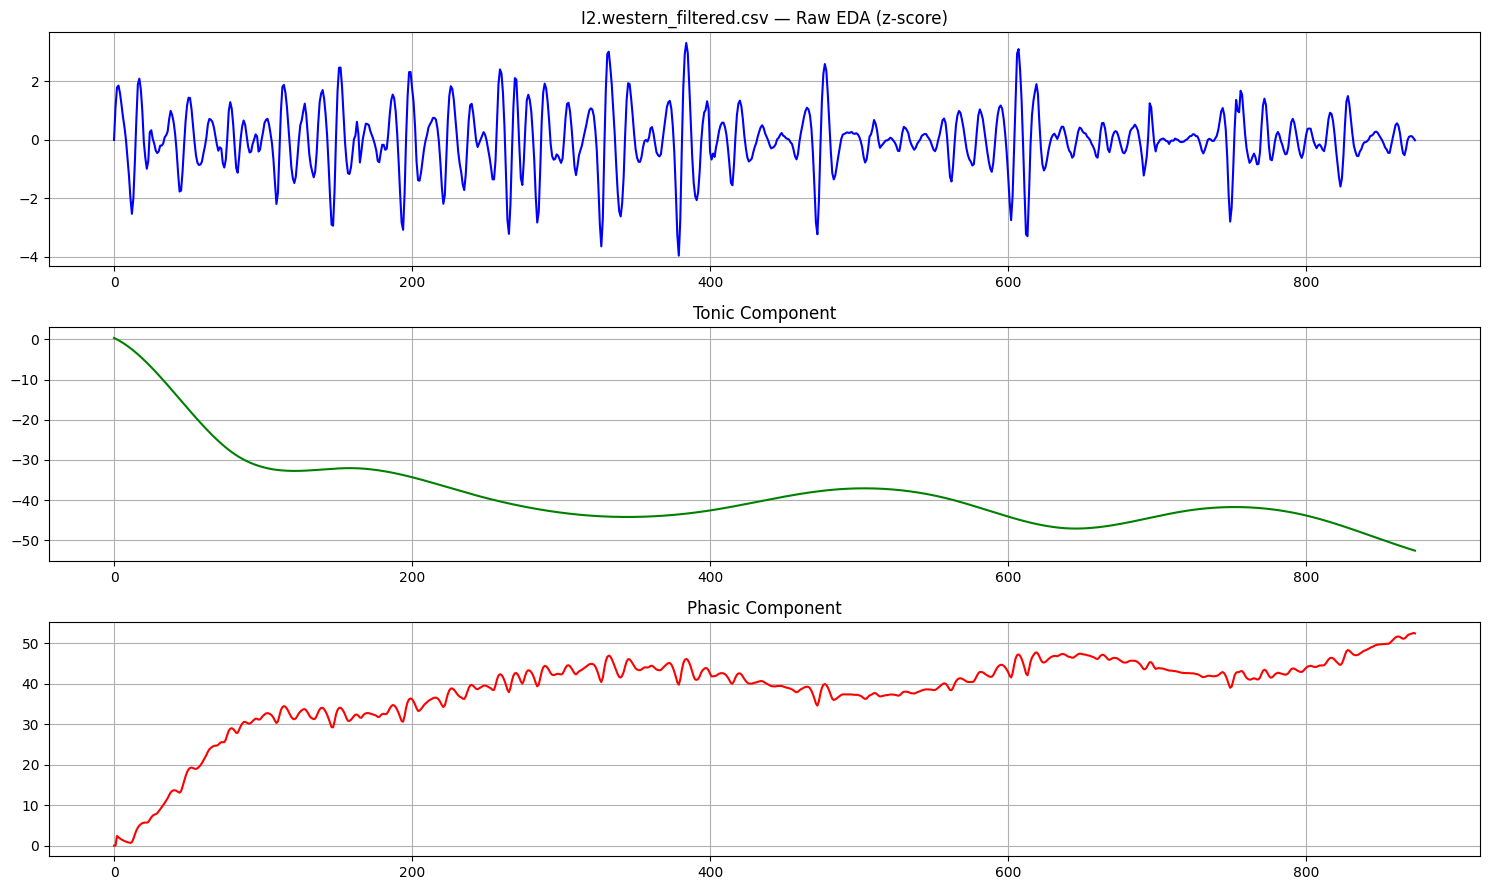

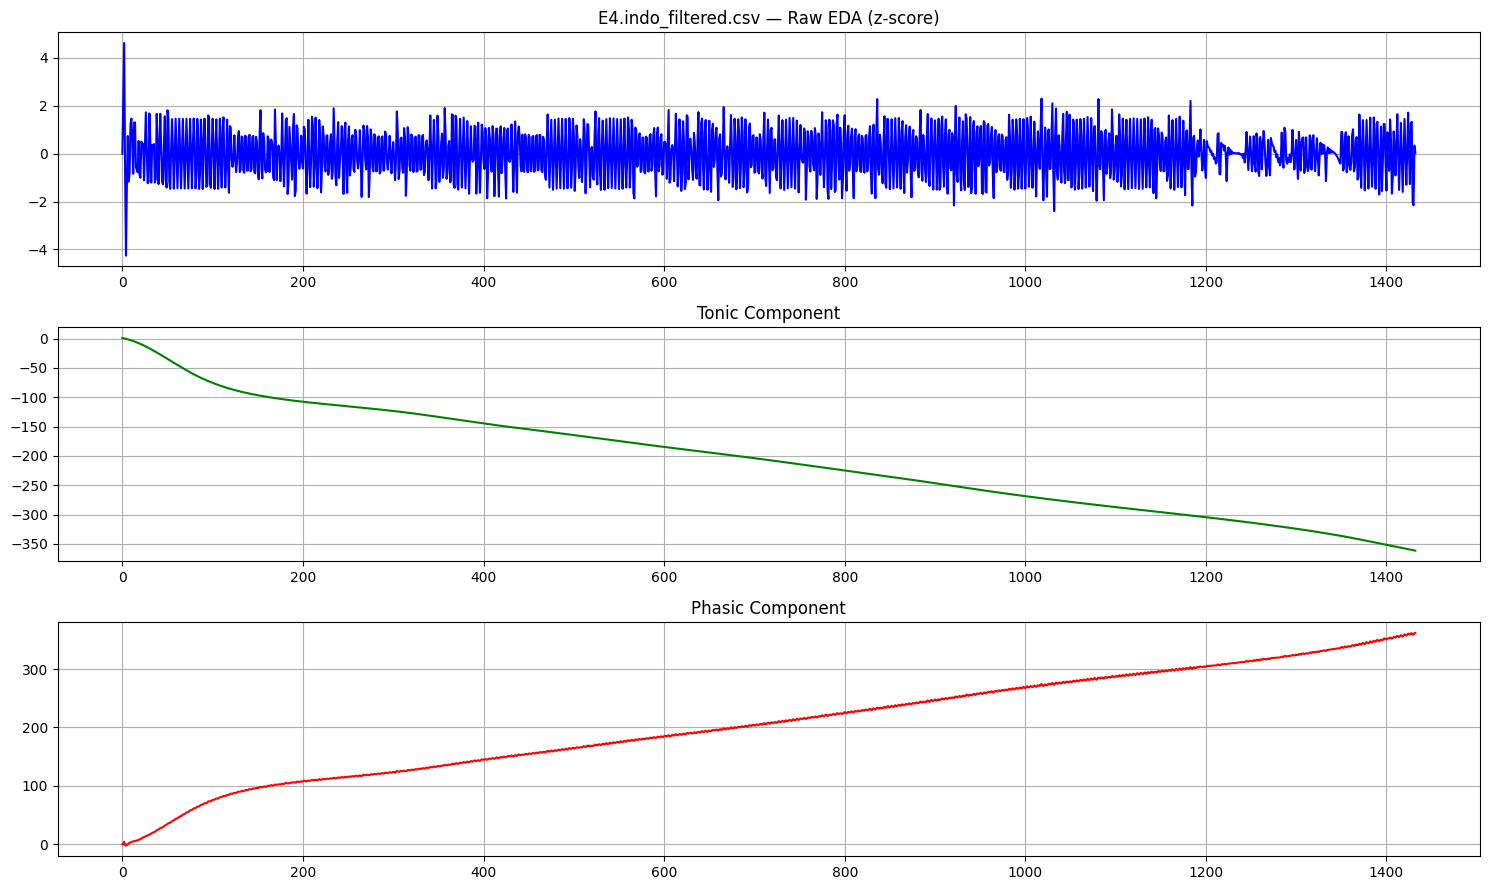

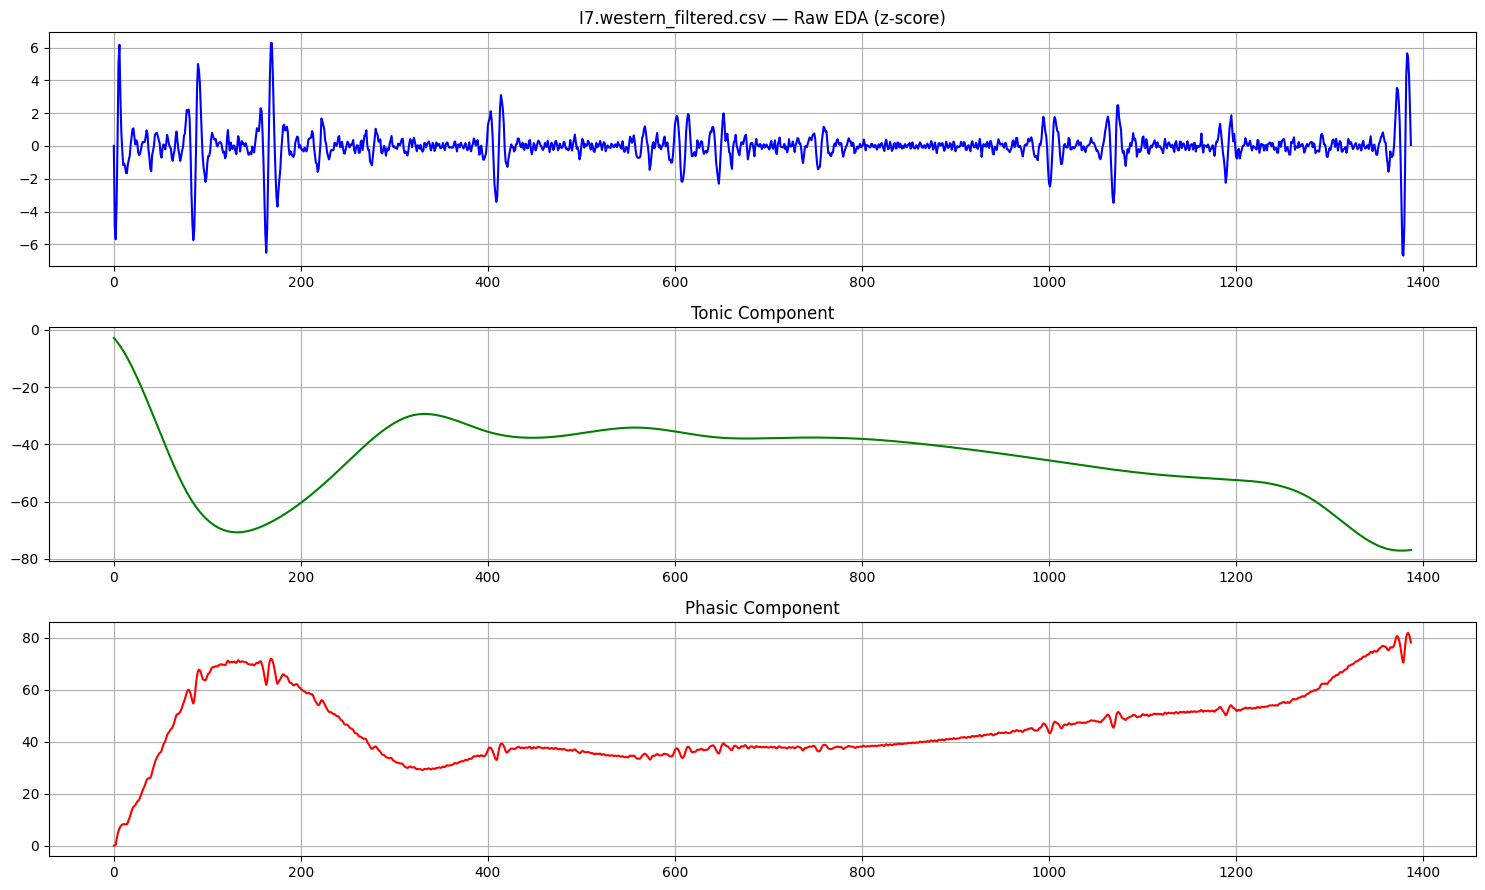

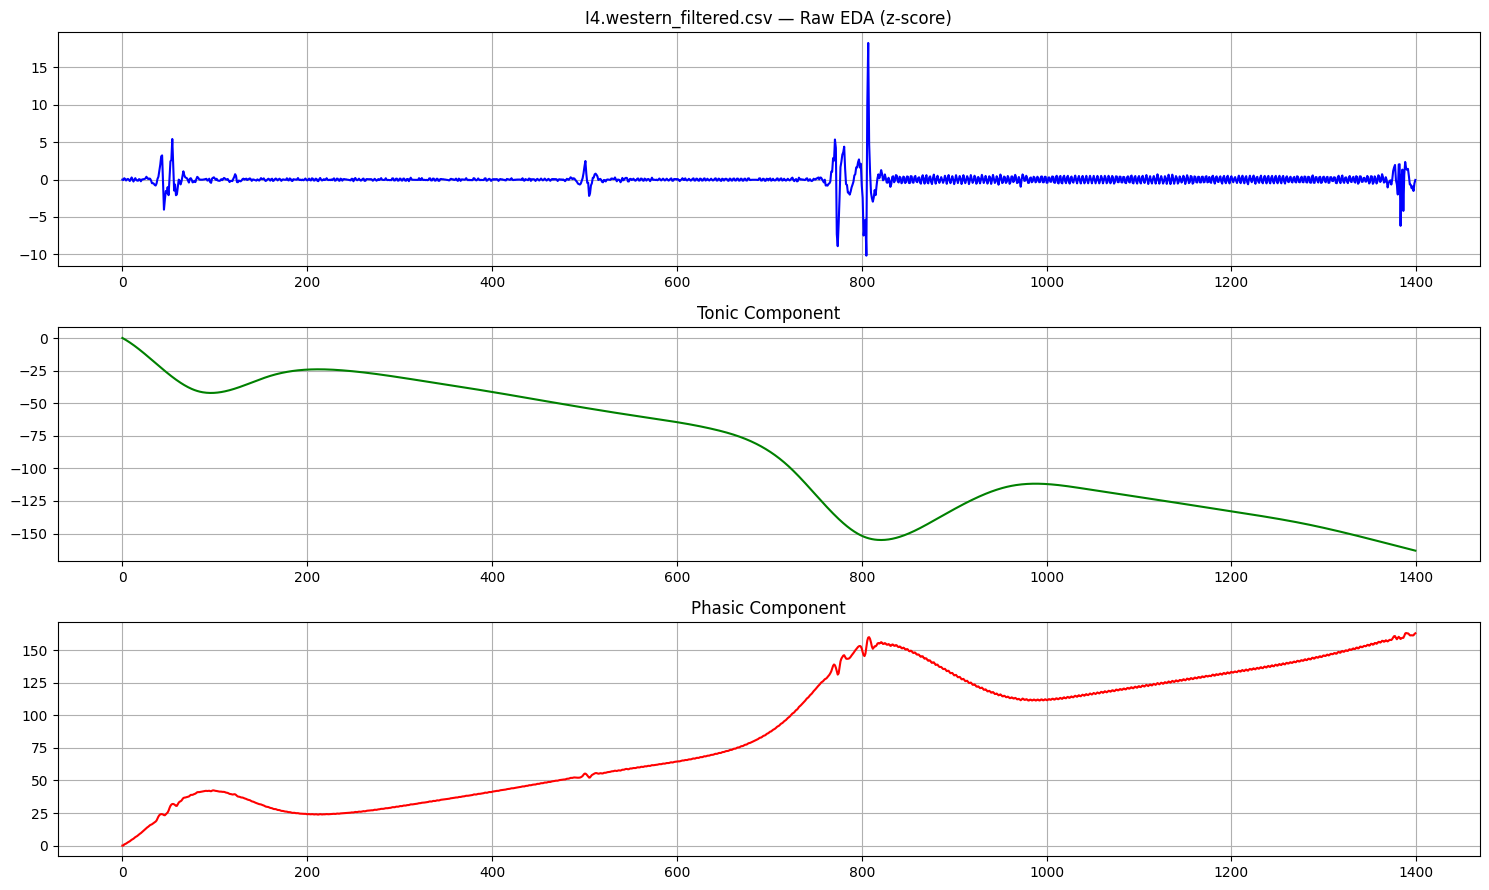

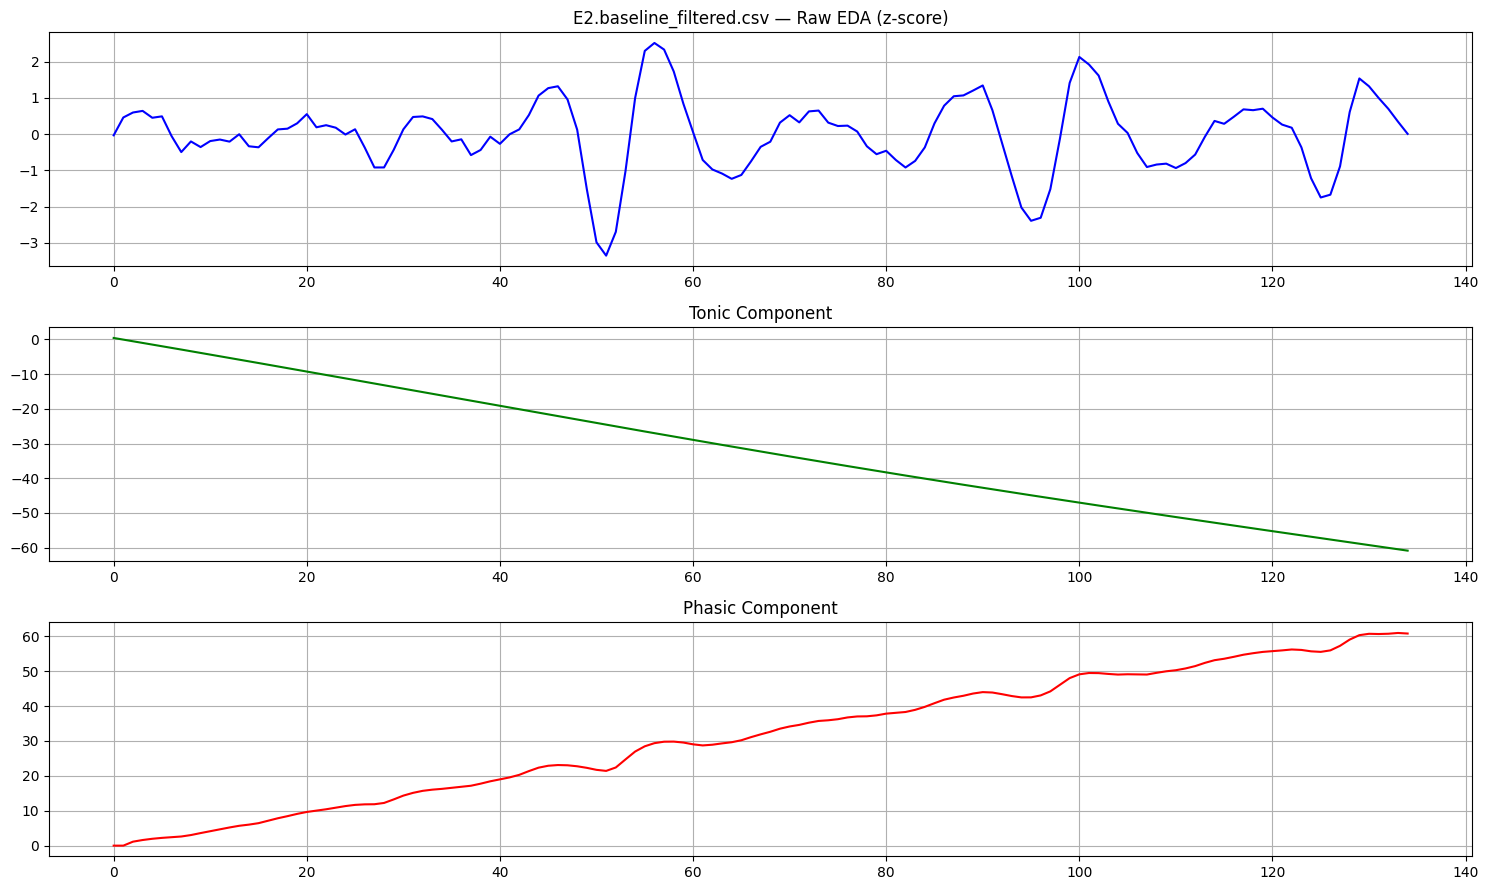

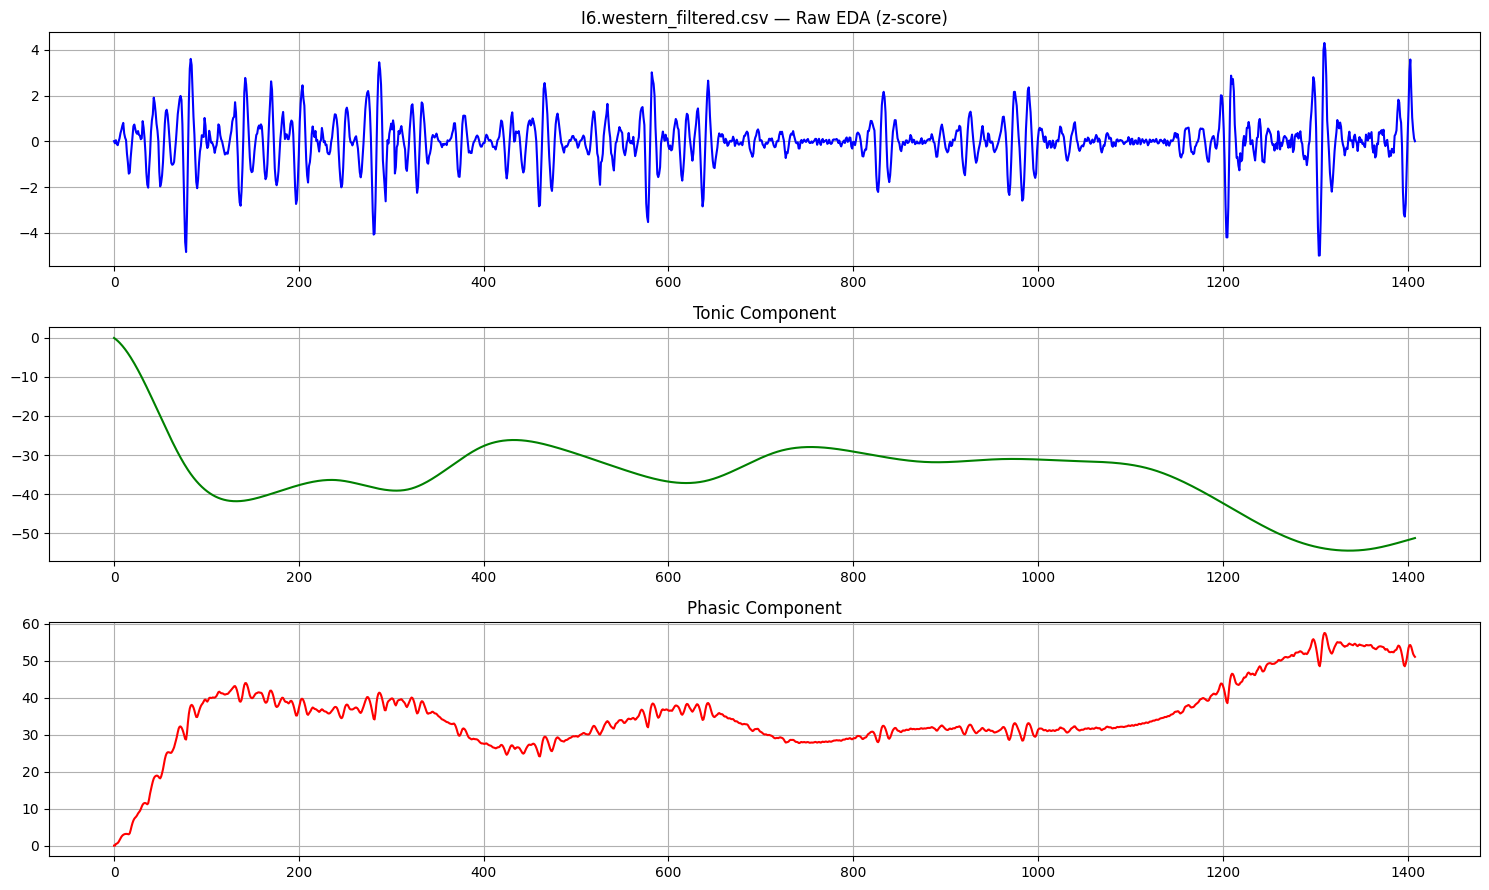

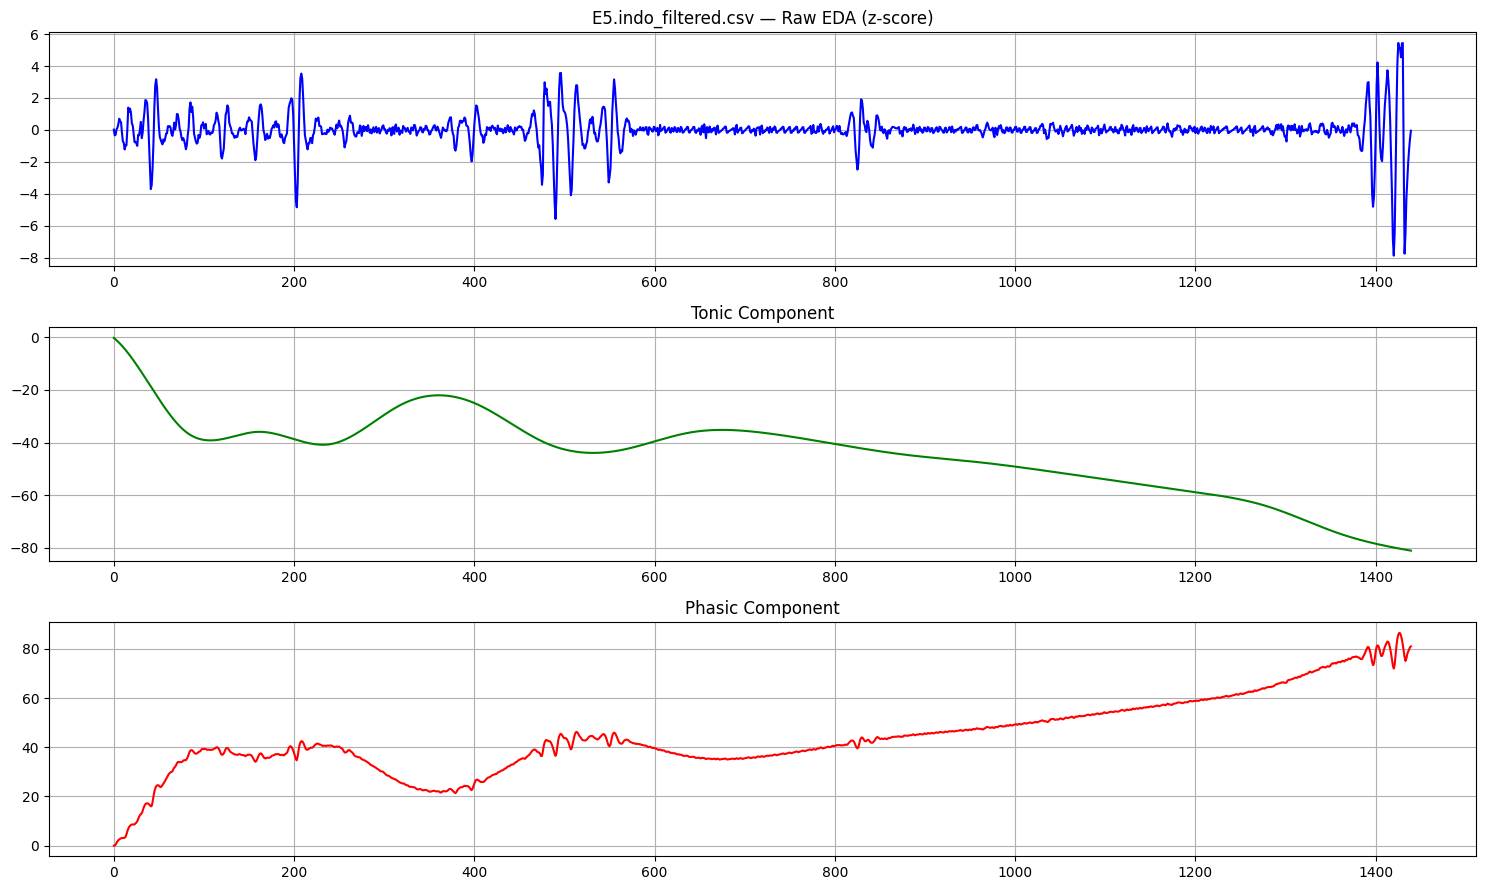

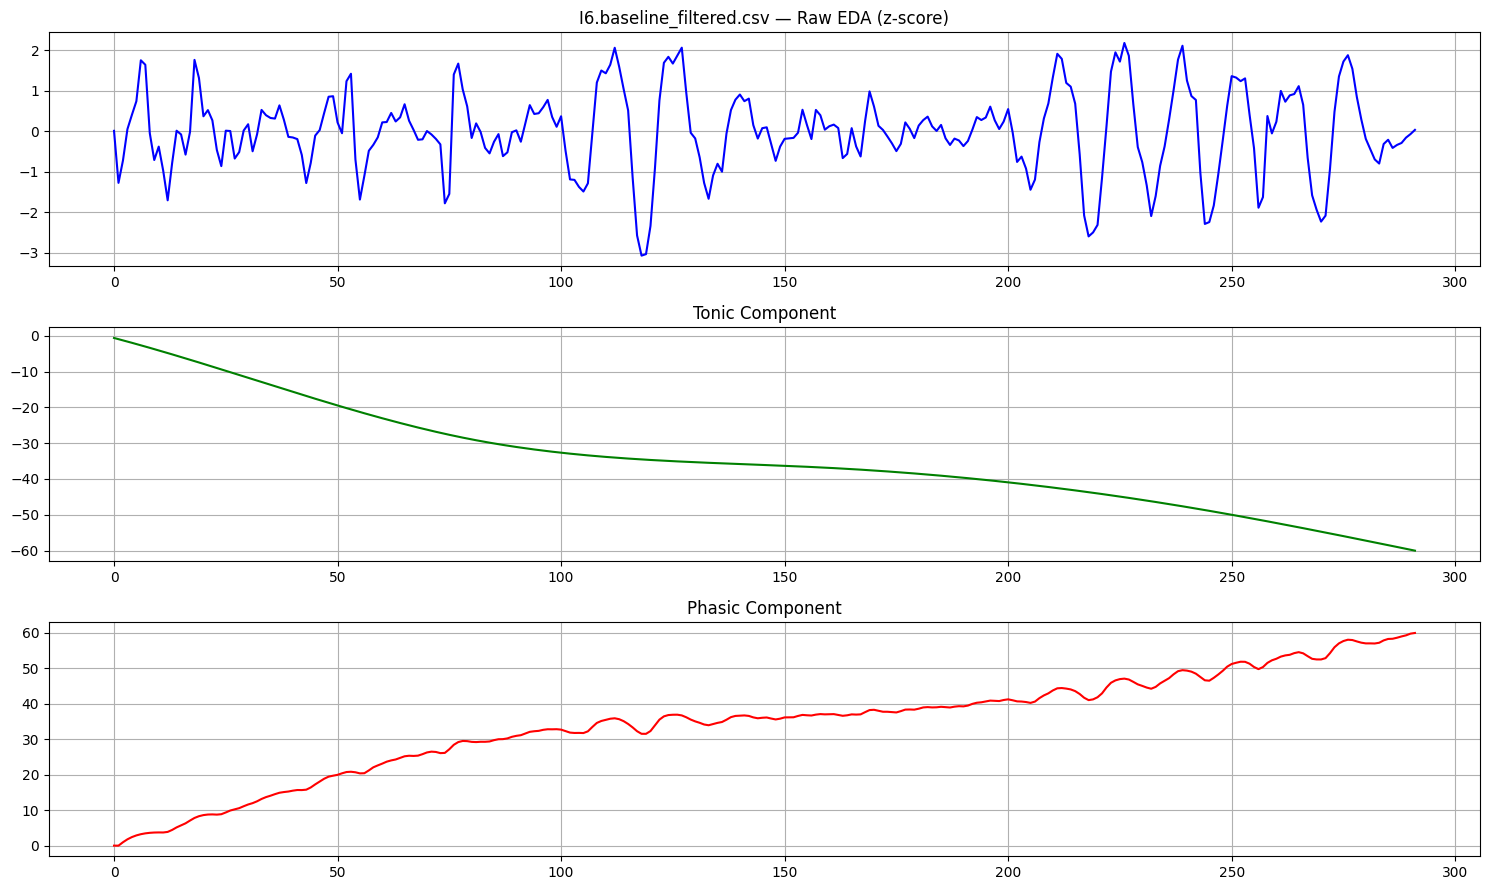


Saved summary to cvxeda_phasic_summary.csv
                        File  MeanPhasic
0   E6.baseline_filtered.csv  133.952713
1   I4.baseline_filtered.csv  165.885083
2   I7.baseline_filtered.csv  192.784874
3   I3.baseline_filtered.csv   28.346616
4    E3.western_filtered.csv   36.349939
5       E6.indo_filtered.csv   91.201276
6       I3.indo_filtered.csv   34.398525
7    E7.western_filtered.csv   39.370258
8       I1.indo_filtered.csv   42.209458
9    I1.western_filtered.csv   44.500021
10  E5.baseline_filtered.csv   45.105951
11   I3.western_filtered.csv   34.031405
12      I2.indo_filtered.csv   47.691598
13   E5.western_filtered.csv   32.682851
14      E7.indo_filtered.csv   50.975067
15   E2.western_filtered.csv   36.078528
16  E3.baseline_filtered.csv   34.383338
17   I5.western_filtered.csv   16.628440
18      I4.indo_filtered.csv  167.785360
19  E7.baseline_filtered.csv  174.942068
20  I5.baseline_filtered.csv  103.179643
21  I2.baseline_filtered.csv   78.986589
22      I5.in

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.signal import find_peaks
import cvxopt as cv
import cvxopt.solvers

# =========================
# 1. CVXEDA FUNCTION
# =========================
def cvxEDA(y, delta, tau0=2., tau1=0.7, delta_knot=10., alpha=8e-4, gamma=1e-2,
           solver=None, options={'reltol':1e-9}):

    n = len(y)
    y = cv.matrix(y)

    # bateman ARMA model
    a1 = 1./min(tau1, tau0)
    a0 = 1./max(tau1, tau0)
    ar = np.array([(a1*delta + 2.)*(a0*delta + 2.), 2.*a1*a0*delta**2 - 8.,
                   (a1*delta - 2.)*(a0*delta - 2.)]) / ((a1 - a0) * delta**2)
    ma = np.array([1., 2., 1.])

    i = np.arange(2, n)
    A = cv.spmatrix(np.tile(ar, (n-2,1)), np.c_[i,i,i], np.c_[i,i-1,i-2], (n,n))
    M = cv.spmatrix(np.tile(ma, (n-2,1)), np.c_[i,i,i], np.c_[i,i-1,i-2], (n,n))

    # spline
    delta_knot_s = int(round(delta_knot / delta))
    spl = np.r_[np.arange(1.,delta_knot_s), np.arange(delta_knot_s, 0., -1.)]
    spl = np.convolve(spl, spl, 'full')
    spl /= max(spl)

    i = np.c_[np.arange(-(len(spl)//2), (len(spl)+1)//2)] + np.r_[np.arange(0,n,delta_knot_s)]
    nB = i.shape[1]
    j = np.tile(np.arange(nB), (len(spl),1))
    p = np.tile(spl, (nB,1)).T
    valid = (i >= 0) & (i < n)
    B = cv.spmatrix(p[valid], i[valid], j[valid])

    C = cv.matrix(np.c_[np.ones(n), np.arange(1., n+1.)/n])
    nC = C.size[1]

    old_options = cv.solvers.options.copy()
    cv.solvers.options.clear()
    cv.solvers.options.update(options)

    Mt, Ct, Bt = M.T, C.T, B.T
    H = cv.sparse([[Mt*M, Ct*M, Bt*M],
                   [Mt*C, Ct*C, Bt*C],
                   [Mt*B, Ct*B, Bt*B + gamma*cv.spmatrix(1.0, range(nB), range(nB))]])

    f = cv.matrix([(cv.matrix(alpha, (1,n)) * A).T - Mt*y,
                   -(Ct*y),
                   -(Bt*y)])

    res = cv.solvers.qp(H, f, cv.spmatrix(-A.V, A.I, A.J, (n,len(f))),
                        cv.matrix(0., (n,1)), solver=solver)

    obj = res['primal objective'] + .5*(y.T*y)

    l = res['x'][-nB:]
    d = res['x'][n:n+nC]
    t = B*l + C*d
    q = res['x'][:n]
    p = A*q
    r = M*q
    e = y - r - t

    cv.solvers.options.clear()
    cv.solvers.options.update(old_options)

    return (np.array(a).ravel() for a in (r, p, t, l, d, e, obj))

# =====================================================
# 2. LOAD ALL FILTERED FILES FROM "Processed" FOLDER
# =====================================================
processed_folder = "Processed"
eda_column = "EDA_Filtered"
sampling_rate = 8
delta = 1 / sampling_rate

eda_z_participants = []
filenames = []

for file in os.listdir(processed_folder):
    if file.endswith("_filtered.csv"):
        path = os.path.join(processed_folder, file)
        df = pd.read_csv(path)

        if eda_column not in df.columns:
            print(f"Skipping {file}: Missing {eda_column}")
            continue

        eda = df[eda_column].dropna().to_numpy()
        if len(eda) == 0:
            print(f"Skipping {file}: EDA empty")
            continue

        eda_z = zscore(eda)

        eda_z_participants.append(eda_z)
        filenames.append(file)

print(f"\nLoaded {len(eda_z_participants)} participants.")

# =====================================================
# 3. RUN CVXEDA FOR ALL PARTICIPANTS
# =====================================================
tonic_all = []
phasic_all = []
smna_all = []

for i, eda_z in enumerate(eda_z_participants):
    print(f"Running cvxEDA on {filenames[i]}")
    r, p, t, l, d, e, obj = cvxEDA(eda_z, delta)
    tonic_all.append(t)
    phasic_all.append(r)
    smna_all.append(p)

# =====================================================
# 4. PHASIC PEAK DETECTION
# =====================================================
MIN_PEAK_HEIGHT = 0.01
MIN_PEAK_DISTANCE = 1.0
distance_samples = int(MIN_PEAK_DISTANCE * sampling_rate)

avg_amplitudes = []

print("\n=== PHASIC PEAK SUMMARY ===")
for i, phasic in enumerate(phasic_all):

    peaks, props = find_peaks(phasic,
                              height=MIN_PEAK_HEIGHT,
                              distance=distance_samples)

    if len(peaks) > 0:
        avg_amp = np.mean(props["peak_heights"])
    else:
        avg_amp = 0

    avg_amplitudes.append(avg_amp)
    print(f"{filenames[i]} → {len(peaks)} peaks, Avg amplitude = {avg_amp:.4f}")

# =====================================================
# 5. PLOT RAW–TONIC–PHASIC
# =====================================================
for i in range(len(eda_z_participants)):
    plt.figure(figsize=(15, 9))

    plt.subplot(3, 1, 1)
    plt.plot(eda_z_participants[i], color="blue")
    plt.title(f"{filenames[i]} — Raw EDA (z-score)")
    plt.grid()

    plt.subplot(3, 1, 2)
    plt.plot(tonic_all[i], color="green")
    plt.title("Tonic Component")
    plt.grid()

    plt.subplot(3, 1, 3)
    plt.plot(phasic_all[i], color="red")
    plt.title("Phasic Component")
    plt.grid()

    plt.tight_layout()
    plt.show()

# =====================================================
# 6. SAVE SUMMARY CSV
# =====================================================

summary_df = pd.DataFrame({
    "File": filenames,
    "MeanPhasic": avg_amplitudes
})

summary_df.to_csv("cvxeda_phasic_summary.csv", index=False)

print("\nSaved summary to cvxeda_phasic_summary.csv")
print(summary_df)